In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dt=pd.read_csv(r'C:\Users\Rutik Bhendarkar\Chat Bot 2\data.csv')
dt

,label,severity_level,severity_score,recommended_action,severity_level_normalized,severity_bucket,action_type,word_count,token_count,char_count,...,symptom_count,body_part_count,duration_count,intensity_count,urgency_count,symptom_entities,body_part_entities,text,text_clean,label_normalized
0,urinary tract infection,High,1,Seek medical attention or professional guidance.,High,high,urgent,18,18,98,...,3,2,1,1,1,urgency; foul-smelling urine; frequent urination,bladder; urinary tract,"At the moment, I have urgent need to urinate, ...",at the moment i have urgent need to urinate fo...,urinary tract infection
1,urinary tract infection,High,1,Seek medical attention or professional guidance.,High,high,urgent,21,21,132,...,5,6,1,1,1,nausea; lower abdominal pain; frequent urinati...,stomach; lower abdomen; pelvis; bladder; urina...,"Since yesterday, I've been dealing with an ups...",since yesterday i ve been dealing with an upse...,urinary tract infection
2,urinary tract infection,High,1,Seek medical attention or professional guidance.,High,high,urgent,22,22,114,...,4,6,1,1,1,nausea; chills; frequent urination; lower abdo...,stomach; body; bladder; urinary tract; lower a...,"For the past 5 days, an upset stomach, feeling...",for the past 5 days an upset stomach feeling c...,urinary tract infection
3,urinary tract infection,High,1,Seek medical attention or professional guidance.,High,high,urgent,23,23,144,...,4,4,1,1,1,lower abdominal pain; foul-smelling urine; chi...,lower abdomen; pelvis; urinary tract; body,"For 3 days, I'm noticing pelvic ache, strong-s...",for 3 days i m noticing pelvic ache strong sme...,urinary tract infection
4,urinary tract infection,High,1,Seek medical attention or professional guidance.,High,high,urgent,27,27,158,...,5,3,1,1,1,fever; foul-smelling urine; blood in urine; fr...,body; urinary tract; bladder,"For about 5 days, I'm noticing fever, foul-sme...",for about 5 days i m noticing fever foul smell...,urinary tract infection
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50395,Pneumonia,High,1,Seek medical attention or professional guidance.,High,high,urgent,16,16,100,...,4,3,1,1,1,sweating; shortness of breath; chills; fever,body; chest; lungs,"Lately, the main problems are sweaty spells, s...",lately the main problems are sweaty spells sho...,pneumonia
50396,Pneumonia,High,1,Seek medical attention or professional guidance.,High,high,urgent,18,18,107,...,3,3,1,1,1,sweating; rapid breathing; sputum,body; lungs; chest,"For the past a week, I'm noticing sweating, ra...",for the past a week i m noticing sweating rapi...,pneumonia
50397,Pneumonia,High,1,Seek medical attention or professional guidance.,High,high,urgent,25,25,161,...,4,2,1,1,1,fever; chills; sputum; chest pain,body; chest,"At the moment, I'm noticing persistent fever, ...",at the moment i m noticing persistent fever sh...,pneumonia
50398,Pneumonia,High,1,Seek medical attention or professional guidance.,High,high,urgent,19,19,115,...,3,3,1,1,1,fatigue; sweating; shortness of breath,body; chest; lungs,"Over the last 3 days, feeling exhausted, sweat...",over the last 3 days feeling exhausted sweatin...,pneumonia


In [3]:
dt.shape

(50400, 22)

In [4]:
dt.isnull().sum()

label                        0
severity_level               0
severity_score               0
recommended_action           0
severity_level_normalized    0
severity_bucket              0
action_type                  0
word_count                   0
token_count                  0
char_count                   0
medical_keyword_count        0
keyword_density              0
symptom_count                0
body_part_count              0
duration_count               0
intensity_count              0
urgency_count                0
symptom_entities             0
body_part_entities           0
text                         0
text_clean                   0
label_normalized             0
dtype: int64

In [5]:
dt.duplicated().sum()

0

In [6]:
# ==========================================
# REMOVE EMPTY TEXT ROWS
# ==========================================

TEXT_COLUMN = "text"
LABEL_COLUMN = "label"

dt = dt.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN])

dt = dt[
    dt[TEXT_COLUMN].astype(str).str.strip() != ""
]

dt.reset_index(drop=True, inplace=True)

print(dt.shape)

(50400, 22)


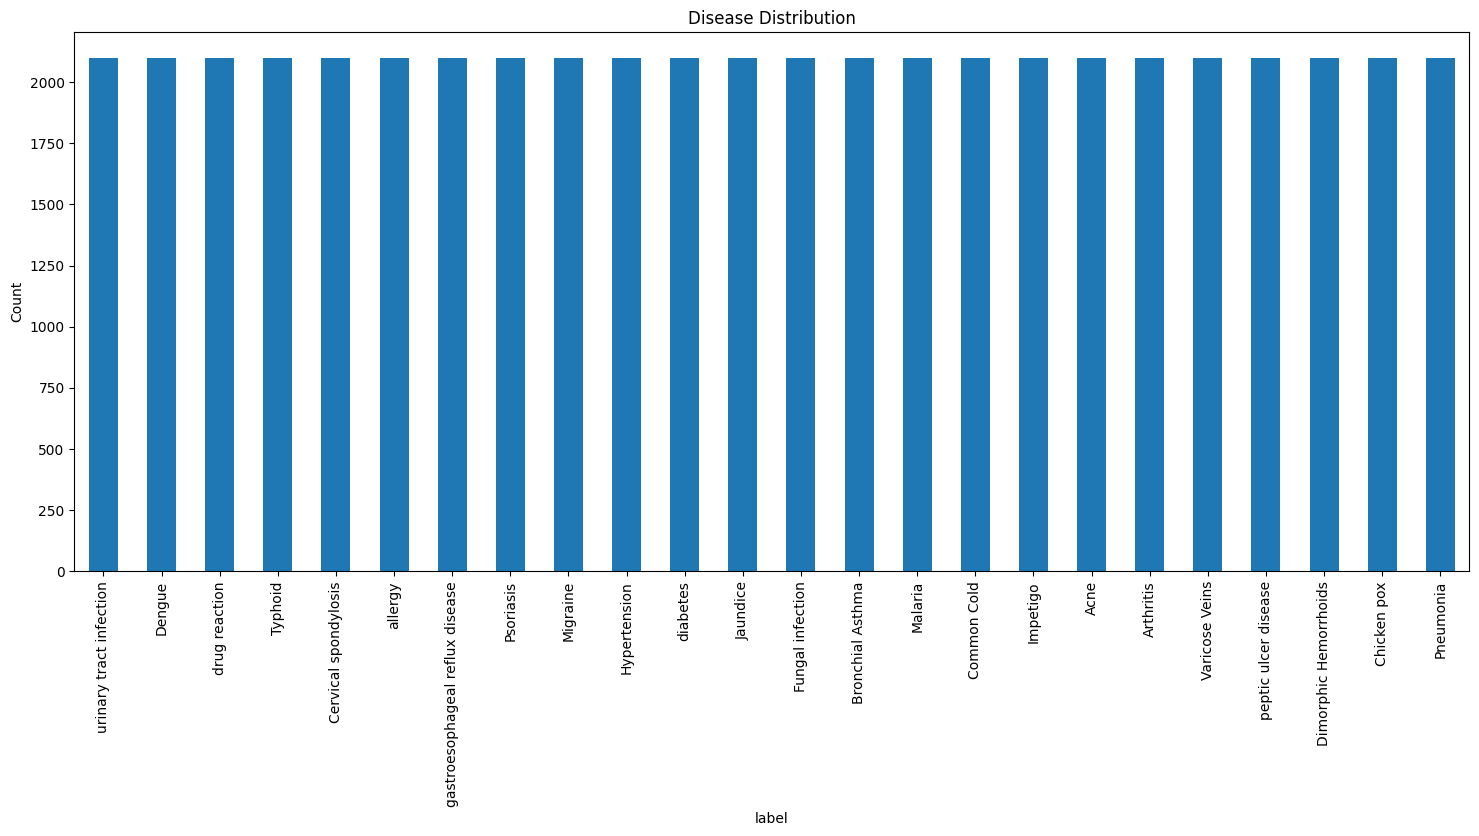

In [7]:
# ==========================================
# VISUALIZE CLASS BALANCE
class_counts = dt["label"].value_counts()
plt.figure(figsize=(18,7))

class_counts.plot(
    kind="bar"
)

plt.title(
    "Disease Distribution"
)

plt.xlabel("label")

plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

In [8]:
# ==========================================
# LABEL NORMALIZATION
# ==========================================

def normalize_label(label):

    label = str(label).strip().lower()

    mapping = {

        "covid": "COVID-19",

        "flu": "Flu",

        "common cold": "Common Cold",

        "uti": "Urinary Tract Infection",

        "gerd": "GERD"

    }

    return mapping.get(label, label.title())


dt[LABEL_COLUMN] = dt[LABEL_COLUMN].apply(
    normalize_label
)

print(
    dt[LABEL_COLUMN].value_counts().head(20)
)

label
Urinary Tract Infection            2100
Dengue                             2100
Drug Reaction                      2100
Typhoid                            2100
Cervical Spondylosis               2100
Allergy                            2100
Gastroesophageal Reflux Disease    2100
Psoriasis                          2100
Migraine                           2100
Hypertension                       2100
Diabetes                           2100
Jaundice                           2100
Fungal Infection                   2100
Bronchial Asthma                   2100
Malaria                            2100
Common Cold                        2100
Impetigo                           2100
Acne                               2100
Arthritis                          2100
Varicose Veins                     2100
Name: count, dtype: int64


In [9]:
# ==========================================
# TEXT LENGTH
# ==========================================

dt["text_length"] = dt["text"].apply(
    lambda x: len(str(x))
)

print(
    dt["text_length"].describe()
)

count    50400.000000
mean       113.498671
std         27.939641
min         38.000000
25%         93.000000
50%        112.000000
75%        132.000000
max        237.000000
Name: text_length, dtype: float64


In [10]:
# ==========================================
# WORD COUNT
# ==========================================

dt["word_count"] = dt["text"].apply(
    lambda x: len(str(x).split())
)

print(
    dt["word_count"].describe()
)

count    50400.000000
mean        19.398452
std          4.914456
min          8.000000
25%         16.000000
50%         19.000000
75%         23.000000
max         42.000000
Name: word_count, dtype: float64


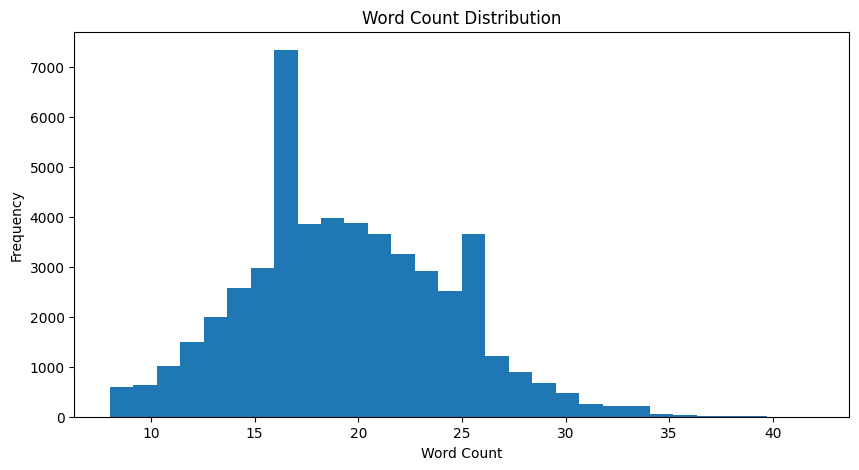

In [11]:
# ==========================================
# WORD COUNT DISTRIBUTION
# ==========================================

plt.figure(figsize=(10,5))

plt.hist(
    dt["word_count"],
    bins=30
)

plt.title(
    "Word Count Distribution"
)

plt.xlabel("Word Count")

plt.ylabel("Frequency")

plt.show()

In [12]:
# ==========================================
# VERY SHORT TEXT
# ==========================================

short_texts = dt[
    dt["word_count"] < 3
]

print(short_texts.shape)

(0, 23)


In [13]:
# ==========================================
# VERY LONG TEXT
# ==========================================

long_texts = dt[
    dt["word_count"] > 50
]

print(long_texts.shape)

(0, 23)


In [14]:
# ==========================================
# MOST COMMON WORDS
# ==========================================

from collections import Counter

all_words = " ".join(
    dt["text"].astype(str)
).lower().split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(30)

print(common_words)

[('and', 65557), ('the', 43916), ('a', 21981), ('i', 20902), ('my', 20507), ('days,', 20206), ('for', 18291), ('in', 17303), ('last', 15509), ('it', 13967), ('feels', 11610), ('with', 9331), ('feeling', 9138), ('is', 9032), ('skin', 8933), ('at', 8873), ('discomfort', 8708), ('have', 8597), ('getting', 8475), ('on', 8420), ('been', 8409), ('after', 7662), ('pain,', 7536), ('pain', 7044), ('week,', 6670), ('about', 6618), ('symptoms', 6446), ('over', 6369), ('since', 6192), ('few', 6065)]


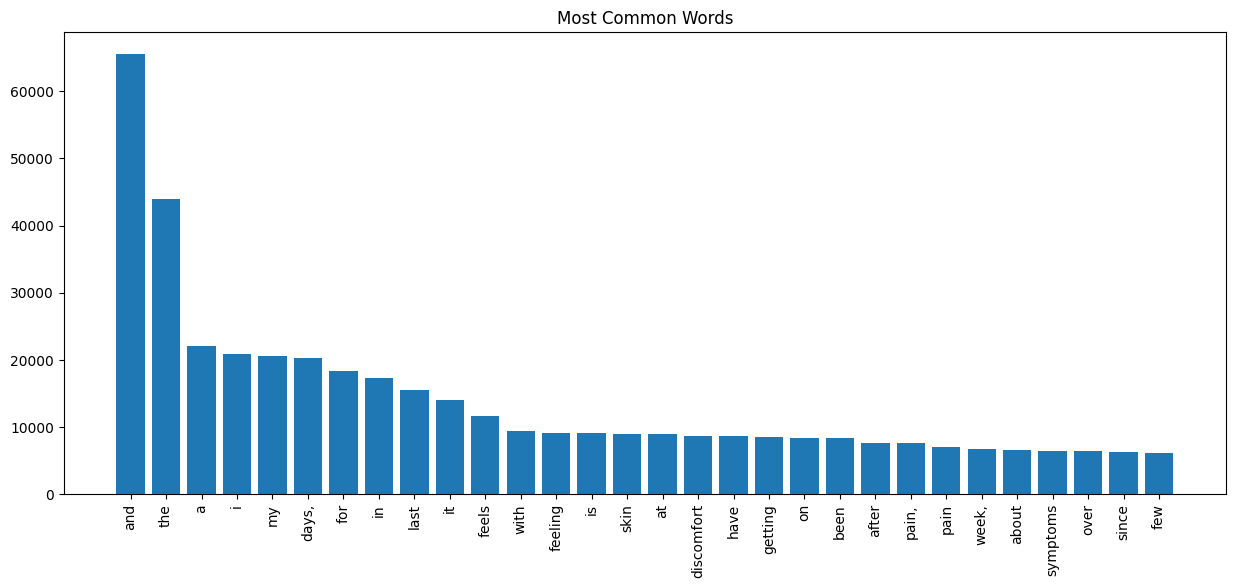

In [15]:
# ==========================================
# WORD FREQUENCY PLOT
# ==========================================

words = [x[0] for x in common_words]

counts = [x[1] for x in common_words]

plt.figure(figsize=(15,6))

plt.bar(words, counts)

plt.xticks(rotation=90)

plt.title("Most Common Words")

plt.show()

In [16]:
# ==========================================
# MOST COMMON WORDS
# ==========================================

from collections import Counter

all_words = " ".join(
    dt["text"].astype(str)
).lower().split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(30)

print(common_words)

[('and', 65557), ('the', 43916), ('a', 21981), ('i', 20902), ('my', 20507), ('days,', 20206), ('for', 18291), ('in', 17303), ('last', 15509), ('it', 13967), ('feels', 11610), ('with', 9331), ('feeling', 9138), ('is', 9032), ('skin', 8933), ('at', 8873), ('discomfort', 8708), ('have', 8597), ('getting', 8475), ('on', 8420), ('been', 8409), ('after', 7662), ('pain,', 7536), ('pain', 7044), ('week,', 6670), ('about', 6618), ('symptoms', 6446), ('over', 6369), ('since', 6192), ('few', 6065)]


In [17]:
# ==========================================
# SPELL CORRECTION
# ==========================================

from textblob import TextBlob


def correct_spelling(text):

    text = str(text)

    try:

        corrected = str(
            TextBlob(text).correct()
        )

        return corrected

    except:

        return text

In [18]:
# ==========================================
# EMERGENCY WORD ANALYSIS
# ==========================================

emergency_words = ["chest","pain","breathing","stroke","fainting","bleeding","unconscious"
]

for word in emergency_words:

    count = dt["text"].str.lower().str.contains(
        word,
        na=False
    ).sum()

    print(word, ":", count)

chest : 4468
pain : 15283
breathing : 3277
stroke : 0
fainting : 0
bleeding : 1270
unconscious : 0


In [19]:
# ==========================================
# SPELLING VARIANTS
# ==========================================

possible_typos = ["fevr","hedache","vomting","breth","stomch"]

for typo in possible_typos:

    count = dt["text"].str.lower().str.contains(
        typo,
        na=False
    ).sum()

    print(typo, ":", count)

fevr : 0
hedache : 0
vomting : 0
breth : 0
stomch : 0


In [20]:
# ==========================================
# DISEASE-SPECIFIC WORDS
# ==========================================

for disease in dt["label"].unique()[:5]:

    disease_text = " ".join(

        dt[
            dt["label"] == disease
        ]["text"].astype(str)

    ).lower().split()

    freq = Counter(disease_text)

    print("\nDisease:", disease)

    print(freq.most_common(10))


Disease: Urinary Tract Infection
[('and', 2827), ('the', 1793), ('a', 1742), ('my', 1435), ('in', 1211), ('i', 1181), ('urine,', 1138), ('to', 979), ('urine', 859), ('days,', 825)]

Disease: Dengue
[('and', 2836), ('the', 2127), ('my', 1321), ('feeling', 865), ('days,', 845), ('for', 800), ('last', 760), ('i', 745), ('a', 697), ('at', 660)]

Disease: Drug Reaction
[('and', 2828), ('the', 1921), ('a', 1598), ('my', 1310), ('days,', 884), ('i', 751), ('for', 655), ('on', 651), ('last', 615), ('is', 588)]

Disease: Typhoid
[('and', 2838), ('the', 1702), ('a', 1163), ('feeling', 1086), ('for', 997), ('last', 929), ('days,', 838), ('i', 787), ('pain,', 674), ('in', 635)]

Disease: Cervical Spondylosis
[('and', 3020), ('my', 2344), ('in', 1757), ('the', 1706), ('neck', 988), ('for', 973), ('pain', 941), ('i', 923), ('days,', 856), ('a', 624)]


In [21]:
class_counts = dt['label'].value_counts()
print("Min Count:", class_counts.min())
print("Max Count:", class_counts.max())
print("Mean Count:", class_counts.mean())


Min Count: 2100
Max Count: 2100
Mean Count: 2100.0


             word_count  text_length
word_count      1.00000      0.93677
text_length     0.93677      1.00000


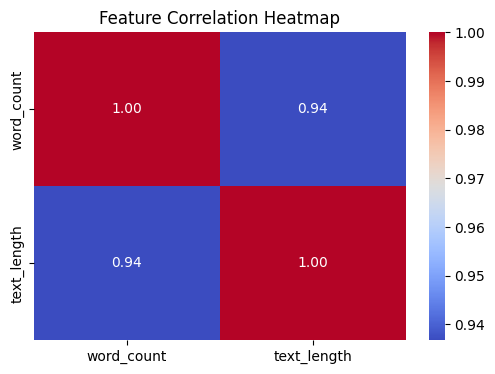

In [22]:
dt["word_count"] = dt["text"].apply(lambda x: len(str(x).split()))

# Text length (number of characters in each text)
dt["text_length"] = dt["text"].apply(lambda x: len(str(x)))

# ✅ Select numeric columns
numeric_cols = ["word_count", "text_length"]

# ✅ Compute correlation matrix
corr = dt[numeric_cols].corr()
print(corr)

# ✅ Visualize correlation with heatmap
plt.figure(figsize=(6,4))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Feature Correlation Heatmap")
plt.show()

In [23]:
# ==========================================
# LOW QUALITY ROWS
# ==========================================

low_quality = dt[
    (dt["word_count"] < 2)
]

print(low_quality.shape)
low_quality.head()

(0, 23)


,label,severity_level,severity_score,recommended_action,severity_level_normalized,severity_bucket,action_type,word_count,token_count,char_count,...,body_part_count,duration_count,intensity_count,urgency_count,symptom_entities,body_part_entities,text,text_clean,label_normalized,text_length


In [24]:
import re
import nltk
import string

from nltk.corpus import stopwords

from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")

nltk.download("wordnet")

nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to C:\Users\Rutik
[nltk_data]     Bhendarkar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Rutik
[nltk_data]     Bhendarkar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Rutik
[nltk_data]     Bhendarkar\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [25]:
stop_words = set(
    stopwords.words("english")
)

important_words = {

    "no",

    "not",

    "with",

    "without",

    "having",

    "against"

}

stop_words = stop_words - important_words

print(
    list(stop_words)[:20]
)

['but', 'who', 'of', 're', 'under', "doesn't", 'why', 'by', 'he', 'and', 'shan', 'when', 'for', 'so', "you're", "wasn't", 'an', 'at', "i've", 'on']


In [26]:
lemmatizer = WordNetLemmatizer()

In [27]:
# ==========================================
# SPELL CORRECTION
# ==========================================

from textblob import TextBlob


def correct_spelling(text):

    text = str(text)

    try:

        corrected = str(
            TextBlob(text).correct()
        )

        return corrected

    except:

        return text

In [28]:
# ==========================================
# MEDICAL SYNONYM MAP
# ==========================================

SYMPTOM_SYNONYMS = {

    "temperature": "fever",

    "high temperature": "fever",

    "body ache": "body pain",

    "body aches": "body pain",

    "head pain": "headache",

    "migraine": "headache",

    "tummy pain": "stomach pain",

    "stomach ache": "stomach pain",

    "throwing up": "vomiting",

    "breathlessness":
        "breathing difficulty",

    "shortness of breath":
        "breathing difficulty",

    "runny nose": "cold",

    "throat pain": "sore throat",

    "burning urine":
        "urine burning",

    "loose motion":
        "diarrhea"

}

In [29]:
# ==========================================
# MEDICAL TERM NORMALIZATION
# ==========================================

def normalize_medical_terms(text):

    text = str(text).lower()

    for key, value in SYMPTOM_SYNONYMS.items():

        text = re.sub(

            rf"\b{re.escape(key)}\b",

            value,

            text

        )

    return text

In [30]:
# ==========================================
# REMOVE PUNCTUATION
# ==========================================

def remove_punctuation(text):

    text = str(text)

    text = text.translate(

        str.maketrans(

            "",

            "",

            string.punctuation

        )

    )

    return text

In [31]:
# ==========================================
# LEMMATIZATION
# ==========================================

def lemmatize_words(words):

    words = [

        lemmatizer.lemmatize(word)

        for word in words

    ]

    return words

In [32]:
def tokenize_text(text):

    return str(text).split()

In [33]:
# ==========================================
# STOPWORD REMOVAL
# ==========================================

def remove_stopwords(words):

    filtered_words = [

        word

        for word in words

        if word not in stop_words

    ]

    return filtered_words

In [34]:
# ==========================================
# REMOVE EXTRA SPACES
# ==========================================

def remove_extra_spaces(text):

    text = re.sub(

        r"\s+",

        " ",

        text

    ).strip()

    return text

In [35]:
# ==========================================
# MAIN NLP PIPELINE
# ==========================================

def preprocess_text(text):

    # convert to string
    text = str(text)

    # lowercase
    text = text.lower()

    # spell correction
    text = correct_spelling(text)

    # normalize medical terms
    text = normalize_medical_terms(text)

    # remove punctuation
    text = remove_punctuation(text)

    # remove extra spaces
    text = remove_extra_spaces(text)

    # tokenize
    words = tokenize_text(text)

    # remove stopwords
    words = remove_stopwords(words)

    # lemmatization
    words = lemmatize_words(words)

    # join text
    text = " ".join(words)

    return text

### Stop Here

In [36]:
TEXT_COLUMN = "text"

dt["clean_text_2"] = dt[
    TEXT_COLUMN
].apply(preprocess_text)

print(dt[[
    TEXT_COLUMN,
    "clean_text_2"
]].head())

                                                text  \
0  At the moment, I have urgent need to urinate, ...   
1  Since yesterday, I've been dealing with an ups...   
2  For the past 5 days, an upset stomach, feeling...   
3  For 3 days, I'm noticing pelvic ache, strong-s...   
4  For about 5 days, I'm noticing fever, foul-sme...   

                                        clean_text_2  
0  moment urgent need private foulsmelling urine ...  
1  since yesterday ive dealing with upset stomach...  
2  past 5 day upset stomach feeling cold shake pr...  
3  3 day im noticing pelvic ache strongsmelling u...  
4  5 day im noticing fever foulsmelling urine uri...  


In [37]:
# ==========================================
# REMOVE EMPTY CLEAN TEXT
# ==========================================

dt=dt[dt['clean_text_2'].str.strip() !=''
]

dt.reset_index(
    drop=True,
    inplace=True
)

print(dt.shape)

(50400, 24)


In [38]:
# ==========================================
# WORD COUNT FEATURE
# ==========================================

dt["word_count"] = dt[
    "clean_text_2"
].apply(
    lambda x: len(str(x).split())
)

print(
    dt["word_count"].describe()
)

count    50400.000000
mean        12.418472
std          3.076655
min          3.000000
25%         10.000000
50%         12.000000
75%         14.000000
max         26.000000
Name: word_count, dtype: float64


In [39]:
# ==========================================
# EMERGENCY KEYWORDS
# ==========================================

EMERGENCY_WORDS = {
    "chest","pain","breathing","difficulty","stroke",
    "fainting","bleeding","unconscious","seizure"
}

def emergency_score(text):
    word=set(
        str(text).split()
    )
    score = sum(

        1

        for word in EMERGENCY_WORDS

        if word in words

    )

    return score


dt["emergency_score"] = dt[
    "clean_text_2"
].apply(
    emergency_score
)

print(
    dt["emergency_score"].describe()
)
    

count    50400.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: emergency_score, dtype: float64


In [40]:
# ==========================================
# SEVERITY KEYWORDS
# ==========================================

SEVERITY_WORDS = {
    "severe","high","intense","extreme","worsening","critical"
}

def severity_score(text):

    words = set(
        str(text).split()
    )

    score = sum(

        1

        for word in SEVERITY_WORDS

        if word in words

    )

    return score

dt['severity_score']=dt['clean_text_2'].apply(severity_score)
print(
    dt["severity_score"].describe()
)

count    50400.000000
mean         0.101012
std          0.316192
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: severity_score, dtype: float64


In [41]:
# ==========================================
# DURATION DETECTION
# ==========================================

DURATION_WORDS = {"day","days","week","weeks","month","months","today","yesterday","since"
}

def duration_score(text):
    words=set(str(text).split())
    score=sum(
          1
           for word in DURATION_WORDS
           if word in words
    )
    return score

dt["duration_score"] = dt[
    "clean_text_2"
].apply(
    duration_score
)

print(
    dt["duration_score"].describe()
)
    

count    50400.000000
mean         0.875456
std          0.652128
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: duration_score, dtype: float64


In [42]:
# ==========================================
# LOW QUALITY INPUT
# ==========================================

dt['low_quality_input']= dt['word_count'].apply(lambda x:
                                               1 if x < 3 else 0
                                              )
print(dt['low_quality_input'].value_counts())

low_quality_input
0    50400
Name: count, dtype: int64


In [43]:
# ==========================================
# DETECTED SYMPTOMS
# ==========================================

KNOWN_SYMPTOMS = {"fever","cough","cold","headache","vomiting","nausea","rash",
                  "itching","pain","weakness","fatigue","breathing","stomach","diarrhea","chills"

}


def extract_detected_symptoms(text):

    words = set(
        str(text).split()
    )

    symptoms = [

        word

        for word in words

        if word in KNOWN_SYMPTOMS

    ]

    return symptoms


dt["detected_symptoms"] = dt[
    "clean_text_2"
].apply(
    extract_detected_symptoms
)

print(dt[[
    "clean_text_2",
    "detected_symptoms"
]].head())

                                        clean_text_2       detected_symptoms
0  moment urgent need private foulsmelling urine ...                      []
1  since yesterday ive dealing with upset stomach...  [fever, stomach, pain]
2  past 5 day upset stomach feeling cold shake pr...         [cold, stomach]
3  3 day im noticing pelvic ache strongsmelling u...                  [cold]
4  5 day im noticing fever foulsmelling urine uri...                 [fever]


In [89]:
dt.to_csv("nlp_processed_healthcare_dataset.csv",index=False)
print(
    "NLP processed dataset saved successfully."
)

NLP processed dataset saved successfully.


In [44]:
dt["unique_word_count"] = dt[
    "clean_text_2"
].apply(

    lambda x:

    len(set(str(x).split()))

)

In [45]:
dt["symptom_density"] = (

    dt["unique_word_count"]

    /

    (dt["word_count"] + 1)

)

In [50]:
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import StandardScaler

from scipy.sparse import hstack

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [51]:
# =========================================================
# STEP 2 — RAW INPUTS
# =========================================================

# text column
X_text_raw = dt["clean_text_2"]

# labels
y_raw = dt["label"]

print(X_text_raw.head())

print("\nTotal Rows:", len(X_text_raw))

0    moment urgent need private foulsmelling urine ...
1    since yesterday ive dealing with upset stomach...
2    past 5 day upset stomach feeling cold shake pr...
3    3 day im noticing pelvic ache strongsmelling u...
4    5 day im noticing fever foulsmelling urine uri...
Name: clean_text_2, dtype: str

Total Rows: 50400


In [52]:
# =========================================================
# STEP 3 — TRAIN TEST SPLIT
# =========================================================

X_train_text, X_test_text, y_train, y_test = train_test_split(

    X_text_raw,

    y_raw,

    test_size=0.2,

    stratify=y_raw,

    random_state=42

)

print("Train Size:", len(X_train_text))

print("Test Size :", len(X_test_text))

Train Size: 40320
Test Size : 10080


In [59]:
vec= TfidfVectorizer( max_features=1000, ngram_range=(1,2),min_df=2,
                     max_df=.95,sublinear_tf=True)

X_train_tfidf= vec.fit_transform(X_train_text)
X_test_tfidf= vec.transform(X_test_text)

print("Train TFIDF Shape:", X_train_tfidf.shape)

print("Test TFIDF Shape :", X_test_tfidf.shape)

Train TFIDF Shape: (40320, 1000)
Test TFIDF Shape : (10080, 1000)


In [60]:
# =========================================================
# STEP 5 — EXTRA FEATURES
# =========================================================

extra_feature_columns = [

    "word_count",

    "emergency_score",

    "severity_score",

    "duration_score",

    "text_length",

    "unique_word_count",

    "symptom_density"

]

# train extra features
X_train_extra = dt.loc[
    X_train_text.index,
    extra_feature_columns
]

# test extra features
X_test_extra = dt.loc[
    X_test_text.index,
    extra_feature_columns
]

print(X_train_extra.shape)

print(X_test_extra.shape)

(40320, 7)
(10080, 7)


In [61]:
# =========================================================
# STEP 6 — SCALE EXTRA FEATURES
# =========================================================

scaler = StandardScaler()

# fit on train
X_train_extra_scaled = scaler.fit_transform(
    X_train_extra
)

# transform test
X_test_extra_scaled = scaler.transform(
    X_test_extra
)

print(X_train_extra_scaled.shape)

print(X_test_extra_scaled.shape)

(40320, 7)
(10080, 7)


In [62]:
# =========================================================
# STEP 7 — COMBINE TFIDF + EXTRA FEATURES
# =========================================================

X_train_final = hstack([

    X_train_tfidf,

    X_train_extra_scaled

])

X_test_final = hstack([

    X_test_tfidf,

    X_test_extra_scaled

])

print("Final Train Shape:", X_train_final.shape)

print("Final Test Shape :", X_test_final.shape)

Final Train Shape: (40320, 1007)
Final Test Shape : (10080, 1007)


In [64]:
# =========================================================
# STEP 8 — TRAIN TEST OVERLAP CHECK
# =========================================================

train_texts = set(X_train_text)

test_texts = set(X_test_text)

overlap = train_texts.intersection(
    test_texts
)

print("Overlap Count:", len(overlap))

Overlap Count: 0


In [67]:
lr_model= LogisticRegression( C=2.0,max_iter=5000,solver='lbfgs',class_weight='balanced',random_state=42)

lr_model.fit(X_train_final,y_train)

lr_pred=lr_model.predict(X_test_final)

lr_accuracy= accuracy_score(y_test,lr_pred)

print("\nLogistic Regression Accuracy:")

print(lr_accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test,lr_pred))


Logistic Regression Accuracy:
0.9940476190476191

Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00       420
                        Allergy       1.00      1.00      1.00       420
                      Arthritis       1.00      1.00      1.00       420
               Bronchial Asthma       1.00      1.00      1.00       420
           Cervical Spondylosis       1.00      1.00      1.00       420
                    Chicken Pox       0.99      0.98      0.99       420
                    Common Cold       0.99      1.00      1.00       420
                         Dengue       0.99      0.97      0.98       420
                       Diabetes       1.00      1.00      1.00       420
          Dimorphic Hemorrhoids       1.00      1.00      1.00       420
                  Drug Reaction       1.00      1.00      1.00       420
               Fungal Infection       0.98      

In [71]:
# =========================================================
# STEP 10 — LINEAR SVM
# =========================================================

svm_model = LinearSVC(

    C=1.5,

    class_weight='balanced',

    max_iter=5000,

    random_state=42

)

print("\nTraining SVM...")

svm_model.fit(

    X_train_final,

    y_train

)

# prediction
svm_pred = svm_model.predict(
    X_test_final
)

# accuracy
svm_accuracy = accuracy_score(

    y_test,

    svm_pred

)

print("\nSVM Accuracy:")

print(svm_accuracy)

print("\nClassification Report:\n")

print(

    classification_report(

        y_test,

        svm_pred

    )

)


Training SVM...

SVM Accuracy:
0.9947420634920635

Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00       420
                        Allergy       1.00      1.00      1.00       420
                      Arthritis       1.00      1.00      1.00       420
               Bronchial Asthma       1.00      1.00      1.00       420
           Cervical Spondylosis       1.00      1.00      1.00       420
                    Chicken Pox       0.99      0.98      0.99       420
                    Common Cold       0.99      1.00      0.99       420
                         Dengue       1.00      0.97      0.98       420
                       Diabetes       1.00      1.00      1.00       420
          Dimorphic Hemorrhoids       1.00      1.00      1.00       420
                  Drug Reaction       1.00      1.00      1.00       420
               Fungal Infection       0.99     

In [72]:
# =========================================================
# STEP 11 — RANDOM FOREST
# =========================================================

rf_model = RandomForestClassifier(

    n_estimators=200,

    max_depth=30,

    min_samples_split=5,

    min_samples_leaf=2,

    class_weight='balanced',

    random_state=42,

    n_jobs=-1

)

print("\nTraining Random Forest...")

rf_model.fit(

    X_train_final,

    y_train

)

# prediction
rf_pred = rf_model.predict(
    X_test_final
)

# accuracy
rf_accuracy = accuracy_score(

    y_test,

    rf_pred

)

print("\nRandom Forest Accuracy:")

print(rf_accuracy)

print("\nClassification Report:\n")

print(

    classification_report(

        y_test,

        rf_pred

    )

)


Training Random Forest...

Random Forest Accuracy:
0.9766865079365079

Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00       420
                        Allergy       1.00      0.99      0.99       420
                      Arthritis       0.99      1.00      0.99       420
               Bronchial Asthma       1.00      1.00      1.00       420
           Cervical Spondylosis       0.99      0.99      0.99       420
                    Chicken Pox       0.99      0.95      0.97       420
                    Common Cold       0.98      0.98      0.98       420
                         Dengue       0.99      0.91      0.95       420
                       Diabetes       1.00      1.00      1.00       420
          Dimorphic Hemorrhoids       1.00      1.00      1.00       420
                  Drug Reaction       0.99      0.97      0.98       420
               Fungal Infec

In [73]:
print("\n========== MODEL COMPARISON ==========\n")

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(f"Linear SVM Accuracy: {svm_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")


========== MODEL COMPARISON ==========

Logistic Regression Accuracy: 0.9940
Linear SVM Accuracy: 0.9947
Random Forest Accuracy: 0.9767


In [81]:
import numpy as np
from scipy.sparse import hstack

def get_top3_predictions(user_input):

    # =====================================
    # CLEAN TEXT
    # =====================================

    cleaned = preprocess_text(
        user_input
    )

    # =====================================
    # TFIDF FEATURES
    # =====================================

    input_tfidf = vec.transform(
        [cleaned]
    )

    # =====================================
    # EXTRA FEATURES
    # =====================================

    word_count = len(cleaned.split())

    text_length = len(cleaned)

    unique_word_count = len(
        set(cleaned.split())
    )

    symptom_density = (
        unique_word_count / word_count
        if word_count > 0 else 0
    )

    emergency_words = [
        "severe",
        "emergency",
        "critical",
        "blood",
        "pain",
        "unconscious"
    ]

    severity_words = [
        "high",
        "extreme",
        "serious",
        "intense"
    ]

    duration_words = [
        "days",
        "weeks",
        "months",
        "long"
    ]

    emergency_score = sum(
        word in cleaned
        for word in emergency_words
    )

    severity_score = sum(
        word in cleaned
        for word in severity_words
    )

    duration_score = sum(
        word in cleaned
        for word in duration_words
    )

    extra_array = np.array([[
        word_count,
        emergency_score,
        severity_score,
        duration_score,
        text_length,
        unique_word_count,
        symptom_density
    ]])

    # =====================================
    # COMBINE FEATURES
    # =====================================

    final_input = hstack([

        input_tfidf,

        extra_array

    ])

    # =====================================
    # PREDICT
    # =====================================

    probs = lr_model.predict_proba(
        final_input
    )[0]

    classes = lr_model.classes_

    top3_idx = np.argsort(
        probs
    )[-3:][::-1]

    results = []

    for idx in top3_idx:

        results.append({

            "disease": classes[idx],

            "confidence": round(
                probs[idx] * 100,
                2
            )

        })

    return results

In [82]:
top3 = get_top3_predictions(

    "I have fever cough headache"

)

print(top3)

[{'disease': 'Typhoid', 'confidence': 48.07}, {'disease': 'Bronchial Asthma', 'confidence': 26.72}, {'disease': 'Cervical Spondylosis', 'confidence': 13.61}]


In [84]:
# ==========================================
# CONFIDENCE GAP ANALYSIS
# ==========================================

def confidence_gap_analysis(top_predictions):

    top1 = top_predictions[0]["confidence"]

    top2 = top_predictions[1]["confidence"]

    gap = round(top1 - top2, 2)

    if gap >= 40:

        confidence_level = "VERY HIGH"

        message = "Prediction is extremely confident."

    elif gap >= 20:

        confidence_level = "HIGH"

        message = "Prediction confidence is high."

    elif gap >= 10:

        confidence_level = "MEDIUM"

        message = "Prediction confidence is moderate."

    else:

        confidence_level = "LOW"

        message = "Prediction is uncertain. More symptoms needed."

    return {

        "gap": gap,

        "confidence_level": confidence_level,

        "message": message

    }

In [85]:
gap_result = confidence_gap_analysis(
    top3
)

print(gap_result)

{'gap': 21.35, 'confidence_level': 'HIGH', 'message': 'Prediction confidence is high.'}


### 3.FOLLOW-UP QUESTION

In [86]:
# ==========================================
# ENHANCED FOLLOW-UP QUESTION DATABASE
# Symptom-based + Disease-based
# ==========================================

FOLLOWUP_QUESTIONS = {

    "fever": [
        "How long have you had the fever?",
        "Is the fever high or mild?",
        "Do you also have chills or body pain?",
        "Did the fever start suddenly or gradually?",
        "Is the fever worse at night?",
        "Do you feel weakness or fatigue?",
        "Have you taken any medicine for the fever?",
        "Do you also have cough or sore throat?"
    ],

    "cough": [
        "Is the cough dry or with mucus?",
        "How long have you been coughing?",
        "Do you have breathing difficulty?",
        "Is the cough worse at night?",
        "Do you have chest pain while coughing?",
        "Do you also have fever or chills?",
        "Are you hearing wheezing sounds?",
        "Do you smoke or have allergies?"
    ],

    "headache": [
        "Is the headache severe or mild?",
        "Do you feel nausea or dizziness?",
        "Is the pain on one side or the whole head?",
        "Do bright lights worsen the headache?",
        "Did the headache start suddenly?",
        "Do you also have fever or neck stiffness?",
        "Do you feel weakness or blurred vision?",
        "Have you been stressed or sleep deprived?"
    ],

    "chest pain": [
        "Is the chest pain sharp or pressure-like?",
        "Does the pain spread to the arm or jaw?",
        "Do you have breathing difficulty?",
        "Did the pain start suddenly?",
        "Does deep breathing worsen the pain?",
        "Do you feel sweating or dizziness?",
        "Is the pain constant or intermittent?",
        "Do you have a history of heart problems?"
    ],

    "stomach pain": [
        "Where exactly is the pain located?",
        "Is the pain severe or mild?",
        "Do you also have vomiting or diarrhea?",
        "Is the pain after eating food?",
        "Do you feel bloating or gas?",
        "Do you have fever with stomach pain?",
        "Did you eat outside food recently?",
        "Does the pain come and go?"
    ],

    "vomiting": [
        "How many times have you vomited today?",
        "Is there blood in the vomit?",
        "Do you feel dehydration?",
        "Do you also have diarrhea?",
        "Did vomiting start after eating?",
        "Do you feel dizziness or weakness?",
        "Are you able to drink water properly?",
        "Do you have stomach cramps?"
    ],

    "diarrhea": [
        "How long have you had diarrhea?",
        "Do you have stomach cramps?",
        "Is there blood in stool?",
        "Did you eat outside food recently?",
        "Do you also have vomiting?",
        "Do you feel dehydration?",
        "Do you have fever or weakness?",
        "Is the diarrhea severe or mild?"
    ],

    "rash": [
        "Is the rash itchy or painful?",
        "Where did the rash first appear?",
        "Did the rash spread quickly?",
        "Do you have fever with the rash?",
        "Have you used any new medicine or soap?",
        "Is the rash red, dry, or swollen?",
        "Do you feel burning sensation?",
        "Are there blisters or peeling skin?"
    ],

    "itching": [
        "Is the itching constant or occasional?",
        "Do you also have rash or redness?",
        "Did it start after using a new product?",
        "Is the itching worse at night?",
        "Do you have dry skin?",
        "Is the itching limited to one area?",
        "Do you also feel swelling?",
        "Do you have allergies?"
    ],

    "breathing difficulty": [
        "Is breathing difficulty severe or mild?",
        "Did it start suddenly?",
        "Do you also have chest pain?",
        "Do you hear wheezing sounds?",
        "Do you feel shortness of breath while walking?",
        "Do you have asthma history?",
        "Is breathing worse at night?",
        "Are your lips turning bluish?"
    ],

    "fatigue": [
        "How long have you been feeling tired?",
        "Do you also have fever or weakness?",
        "Are you sleeping properly?",
        "Do you feel tired after small activities?",
        "Have you lost appetite recently?",
        "Do you feel dizziness?",
        "Do you have stress or anxiety?",
        "Are you drinking enough water?"
    ],

    "weakness": [
        "When did the weakness start?",
        "Is it constant or comes and goes?",
        "Do you also feel dizziness or fatigue?",
        "Is the weakness affecting walking?",
        "Do you have fever with weakness?",
        "Do you have poor appetite?",
        "Have you had vomiting or diarrhea recently?",
        "Do you feel faint?"
    ],

    "nausea": [
        "Have you vomited as well?",
        "Is the nausea after eating food?",
        "Do you have stomach pain?",
        "Do you feel dizzy or weak?",
        "Do you have fever?",
        "Is the nausea constant or occasional?",
        "Did it start suddenly?",
        "Do you feel better after resting?"
    ],

    "dizziness": [
        "Do you feel like the room is spinning?",
        "Did it start suddenly?",
        "Do you also have weakness or nausea?",
        "Have you eaten properly today?",
        "Do you have headache or blurred vision?",
        "Do you feel faint?",
        "Is dizziness worse when standing up?",
        "Do you have fever or dehydration?"
    ],

    "sore throat": [
        "Do you have cough or fever?",
        "Is swallowing painful?",
        "Do you have swollen tonsils?",
        "Is the sore throat mild or severe?",
        "Do you have runny nose?",
        "Is there hoarseness in your voice?",
        "Do you feel body pain?",
        "Did it start suddenly?"
    ],

    "joint pain": [
        "Which joint hurts the most?",
        "Do you also have swelling or stiffness?",
        "Did the pain start after injury?",
        "Is the pain worse in the morning?",
        "Do you have fever?",
        "Is the pain constant or intermittent?",
        "Do you have difficulty moving the joint?",
        "Do you feel weakness or fatigue?"
    ],

    "burning urination": [
        "Do you also feel frequent urination?",
        "Is there lower abdominal pain?",
        "Do you have fever or back pain?",
        "Is the urine cloudy or foul-smelling?",
        "Do you feel urgency to urinate?",
        "Do you see blood in urine?",
        "Did the burning start suddenly?",
        "Do you have a history of UTI?"
    ]
}

# ==========================================
# DISEASE-BASED FOLLOW-UP QUESTIONS
# (used after prediction for better variety)
# ==========================================

DISEASE_FOLLOWUP_QUESTIONS = {

    "Flu": [
        "Do you also have chills and body pain?",
        "How many days have you been feeling sick?",
        "Do you have sore throat or cough?",
        "Is the fever high or mild?"
    ],

    "Common Cold": [
        "Do you have a runny nose or sneezing?",
        "Is the cough dry or with mucus?",
        "Do you also have sore throat?",
        "Is the fever present or absent?"
    ],

    "Dengue": [
        "Do you have headache behind the eyes?",
        "Are you feeling severe body pain?",
        "Do you have rash or weakness?",
        "How many days have you had the fever?"
    ],

    "Malaria": [
        "Do you get fever with chills?",
        "Is the fever coming and going?",
        "Do you have sweating or weakness?",
        "Have you traveled recently?"
    ],

    "Typhoid": [
        "Do you have stomach pain or constipation?",
        "Is the fever continuous?",
        "Do you also have weakness or nausea?",
        "Have you had loss of appetite?"
    ],

    "COVID-19": [
        "Do you have cough and breathing difficulty?",
        "Have you lost smell or taste?",
        "Do you also have fever or sore throat?",
        "How long have the symptoms been present?"
    ],

    "Pneumonia": [
        "Do you feel chest pain while breathing?",
        "Do you have high fever or chills?",
        "Is the cough producing mucus?",
        "Are you feeling shortness of breath?"
    ],

    "Bronchial Asthma": [
        "Do you hear wheezing while breathing?",
        "Do you have tightness in the chest?",
        "Is breathing worse at night?",
        "Do you use any inhaler medicine?"
    ],

    "GERD": [
        "Do you feel burning in the chest after meals?",
        "Do spicy foods make it worse?",
        "Do you get acid reflux or burping?",
        "Is it worse at night or after lying down?"
    ],

    "Migraine": [
        "Is the headache one-sided?",
        "Do bright lights make it worse?",
        "Do you feel nausea or vomiting?",
        "Have you experienced migraines before?"
    ],

    "Urinary Tract Infection": [
        "Do you feel burning while urinating?",
        "Do you have frequent urination?",
        "Is there lower abdominal pain?",
        "Do you have fever or back pain?"
    ],

    "Allergy": [
        "Did symptoms start after food, dust, or medicine exposure?",
        "Do you have itching or rash?",
        "Are your eyes watery or itchy?",
        "Do you also have sneezing or swelling?"
    ],

    "Gastroenteritis": [
        "Do you have vomiting and diarrhea together?",
        "Did the symptoms start after eating outside food?",
        "Do you have stomach cramps?",
        "Are you feeling dehydrated?"
    ],

    "Jaundice": [
        "Do your eyes or skin look yellow?",
        "Do you have dark urine?",
        "Do you feel weakness or stomach pain?",
        "Have you lost appetite recently?"
    ]
}

# ==========================================
# HELPERS
# ==========================================

def detect_symptoms(text):
    text = text.lower()
    detected = []

    for symptom in FOLLOWUP_QUESTIONS.keys():
        if symptom in text:
            detected.append(symptom)

    return detected


def generate_followup_questions(user_input, predicted_disease=None, max_questions=5):
    questions = []

    # symptom-based questions
    symptoms = detect_symptoms(user_input)
    for symptom in symptoms:
        questions.extend(FOLLOWUP_QUESTIONS.get(symptom, []))

    # disease-based questions
    if predicted_disease:
        questions.extend(DISEASE_FOLLOWUP_QUESTIONS.get(predicted_disease, []))

    # remove duplicates while preserving order
    unique_questions = []
    seen = set()
    for q in questions:
        if q not in seen:
            unique_questions.append(q)
            seen.add(q)

    return unique_questions[:max_questions]

In [87]:
qs = generate_followup_questions(
    "I have fever cough and headache",
    predicted_disease="Flu",
    max_questions=5
)

for q in qs:
    print("-", q)

- How long have you had the fever?
- Is the fever high or mild?
- Do you also have chills or body pain?
- Did the fever start suddenly or gradually?
- Is the fever worse at night?


### 4.EMERGENCY DETECTION SYSTEM

In [88]:
# ==========================================
# EXPANDED EMERGENCY PATTERNS
# ==========================================

EMERGENCY_PATTERNS = [

    {
        "name": "Cardiac Emergency",
        "keywords": ["chest pain", "chest tightness", "pressure in chest", "pain in chest"],
        "severity": "CRITICAL",
        "message": "Possible heart-related emergency. Seek immediate medical attention."
    },

    {
        "name": "Severe Breathing Emergency",
        "keywords": ["breathing difficulty", "shortness of breath", "cannot breathe", "severe wheezing"],
        "severity": "CRITICAL",
        "message": "Severe breathing difficulty detected. Seek urgent medical help immediately."
    },

    {
        "name": "Stroke Warning",
        "keywords": ["slurred speech", "face drooping", "one sided weakness", "sudden weakness", "stroke"],
        "severity": "CRITICAL",
        "message": "Possible stroke symptoms detected. Call emergency services immediately."
    },

    {
        "name": "Severe Bleeding",
        "keywords": ["heavy bleeding", "uncontrolled bleeding", "bleeding too much", "blood loss"],
        "severity": "CRITICAL",
        "message": "Severe bleeding detected. Emergency medical care is needed immediately."
    },

    {
        "name": "Loss of Consciousness",
        "keywords": ["unconscious", "fainted", "passed out", "loss of consciousness"],
        "severity": "CRITICAL",
        "message": "Loss of consciousness detected. Seek emergency help immediately."
    },

    {
        "name": "Seizure Emergency",
        "keywords": ["seizure", "fits", "convulsions", "shaking uncontrollably"],
        "severity": "CRITICAL",
        "message": "Possible seizure detected. Emergency medical attention is recommended."
    },

    {
        "name": "Severe Allergic Reaction",
        "keywords": ["swelling face", "swollen lips", "swollen tongue", "hives", "allergic reaction", "throat closing"],
        "severity": "CRITICAL",
        "message": "Possible severe allergic reaction detected. Seek immediate medical help."
    },

    {
        "name": "Very High Fever Risk",
        "keywords": ["high fever", "very high fever", "fever with confusion", "fever and confusion"],
        "severity": "HIGH",
        "message": "High fever with warning signs detected. Medical evaluation is recommended."
    },

    {
        "name": "Severe Dehydration",
        "keywords": ["severe dehydration", "cannot drink", "dry mouth", "little urine", "no urine", "very weak"],
        "severity": "HIGH",
        "message": "Severe dehydration symptoms detected. Medical attention may be needed."
    },

    {
        "name": "Appendicitis Warning",
        "keywords": ["right lower abdominal pain", "lower right stomach pain", "appendix pain", "severe stomach pain"],
        "severity": "HIGH",
        "message": "Possible abdominal emergency detected. Please seek medical evaluation quickly."
    },

    {
        "name": "Heart Attack Warning",
        "keywords": ["chest pain", "sweating", "pain in arm", "jaw pain", "nausea", "pressure in chest"],
        "severity": "CRITICAL",
        "message": "Symptoms may indicate a heart attack. Call emergency services immediately."
    },

    {
        "name": "Pneumonia Warning",
        "keywords": ["fever", "cough", "breathing difficulty", "chest pain", "mucus"],
        "severity": "HIGH",
        "message": "Possible severe lung infection detected. Medical assessment is recommended."
    }
]


# ==========================================
# EMERGENCY DETECTION FUNCTION
# ==========================================

def detect_emergency(user_input):
    text = user_input.lower()
    alerts = []

    for pattern in EMERGENCY_PATTERNS:
        matched = all(keyword in text for keyword in pattern["keywords"])

        # Special case: some patterns should trigger if ANY one of the listed keywords appears.
        # For now, keep all() for strict patterns. If you want looser matching, tell me and I'll convert it.

        if matched:
            alerts.append({
                "emergency": pattern["name"],
                "severity": pattern["severity"],
                "message": pattern["message"]
            })

    return alerts

In [89]:
# ==========================================
# SMARTER EMERGENCY PATTERNS
# ==========================================

EMERGENCY_PATTERNS = [

    {
        "name": "Cardiac Emergency",
        "any_keywords": ["chest pain", "chest tightness", "pressure in chest", "pain in chest"],
        "severity": "CRITICAL",
        "message": "Possible heart-related emergency. Seek immediate medical attention."
    },

    {
        "name": "Severe Breathing Emergency",
        "any_keywords": ["breathing difficulty", "shortness of breath", "cannot breathe", "severe wheezing"],
        "severity": "CRITICAL",
        "message": "Severe breathing difficulty detected. Seek urgent medical help immediately."
    },

    {
        "name": "Stroke Warning",
        "any_keywords": ["slurred speech", "face drooping", "one sided weakness", "sudden weakness", "stroke"],
        "severity": "CRITICAL",
        "message": "Possible stroke symptoms detected. Call emergency services immediately."
    },

    {
        "name": "Severe Bleeding",
        "any_keywords": ["heavy bleeding", "uncontrolled bleeding", "blood loss"],
        "severity": "CRITICAL",
        "message": "Severe bleeding detected. Emergency medical care is needed immediately."
    },

    {
        "name": "Loss of Consciousness",
        "any_keywords": ["unconscious", "fainted", "passed out", "loss of consciousness"],
        "severity": "CRITICAL",
        "message": "Loss of consciousness detected. Seek emergency help immediately."
    },

    {
        "name": "Seizure Emergency",
        "any_keywords": ["seizure", "fits", "convulsions", "shaking uncontrollably"],
        "severity": "CRITICAL",
        "message": "Possible seizure detected. Emergency medical attention is recommended."
    },

    {
        "name": "Severe Allergic Reaction",
        "any_keywords": ["swelling face", "swollen lips", "swollen tongue", "hives", "allergic reaction", "throat closing"],
        "severity": "CRITICAL",
        "message": "Possible severe allergic reaction detected. Seek immediate medical help."
    },

    {
        "name": "Very High Fever Risk",
        "any_keywords": ["very high fever", "fever with confusion", "fever and confusion"],
        "severity": "HIGH",
        "message": "High fever with warning signs detected. Medical evaluation is recommended."
    },

    {
        "name": "Severe Dehydration",
        "any_keywords": ["severe dehydration", "cannot drink", "dry mouth", "little urine", "no urine", "very weak"],
        "severity": "HIGH",
        "message": "Severe dehydration symptoms detected. Medical attention may be needed."
    },

    {
        "name": "Appendicitis Warning",
        "any_keywords": ["right lower abdominal pain", "lower right stomach pain", "appendix pain"],
        "severity": "HIGH",
        "message": "Possible abdominal emergency detected. Please seek medical evaluation quickly."
    },

    {
        "name": "Heart Attack Warning",
        "any_keywords": ["jaw pain", "pain in arm", "sweating", "nausea", "pressure in chest"],
        "all_keywords": ["chest pain"],
        "severity": "CRITICAL",
        "message": "Symptoms may indicate a heart attack. Call emergency services immediately."
    }
]


def detect_emergency(user_input):
    text = user_input.lower()
    alerts = []

    for pattern in EMERGENCY_PATTERNS:
        any_keywords = pattern.get("any_keywords", [])
        all_keywords = pattern.get("all_keywords", [])

        any_match = True if not any_keywords else any(k in text for k in any_keywords)
        all_match = True if not all_keywords else all(k in text for k in all_keywords)

        if any_match and all_match:
            alerts.append({
                "emergency": pattern["name"],
                "severity": pattern["severity"],
                "message": pattern["message"]
            })

    return alerts

In [90]:
tests = [
    "I have chest pain and breathing difficulty",
    "I fainted and now I am unconscious",
    "I have swelling on my lips and throat closing",
    "I have fever and confusion",
    "I have severe stomach pain on the right side"
]

for t in tests:
    print(t)
    print(detect_emergency(t))
    print("-" * 60)

I have chest pain and breathing difficulty
[{'emergency': 'Cardiac Emergency', 'severity': 'CRITICAL', 'message': 'Possible heart-related emergency. Seek immediate medical attention.'}, {'emergency': 'Severe Breathing Emergency', 'severity': 'CRITICAL', 'message': 'Severe breathing difficulty detected. Seek urgent medical help immediately.'}]
------------------------------------------------------------
I fainted and now I am unconscious
[{'emergency': 'Loss of Consciousness', 'severity': 'CRITICAL', 'message': 'Loss of consciousness detected. Seek emergency help immediately.'}]
------------------------------------------------------------
I have swelling on my lips and throat closing
[{'emergency': 'Severe Allergic Reaction', 'severity': 'CRITICAL', 'message': 'Possible severe allergic reaction detected. Seek immediate medical help.'}]
------------------------------------------------------------
I have fever and confusion
[{'emergency': 'Very High Fever Risk', 'severity': 'HIGH', 'messa

### 5.EXPLAINABLE AI SYSTEM

In [91]:
# ==========================================
# EXPANDED KNOWN SYMPTOMS
# ==========================================

KNOWN_SYMPTOMS = [
    "fever", "high fever", "low fever",
    "cough", "dry cough", "productive cough",
    "headache", "migraine", "head pain",
    "body pain", "muscle pain", "joint pain",
    "stomach pain", "abdominal pain", "cramps",
    "chest pain", "chest tightness",
    "breathing difficulty", "shortness of breath", "wheezing",
    "vomiting", "nausea", "diarrhea", "constipation",
    "fatigue", "weakness", "tiredness",
    "rash", "itching", "hives", "redness",
    "sore throat", "throat pain", "swollen throat",
    "runny nose", "sneezing", "blocked nose",
    "dizziness", "fainting", "blurred vision",
    "chills", "sweating", "dehydration",
    "loss of smell", "loss of taste",
    "swelling", "burning urination", "frequent urination",
    "back pain", "lower abdominal pain",
    "neck stiffness", "confusion"
]

# ==========================================
# EXPANDED DISEASE REASONING
# ==========================================

DISEASE_REASONING = {
    "Flu": "Flu often causes fever, cough, chills, body pain, headache, and weakness.",
    "Common Cold": "Common cold usually causes runny nose, sneezing, cough, sore throat, and mild fever.",
    "COVID-19": "COVID-19 often causes fever, cough, fatigue, breathing issues, loss of smell, and sore throat.",
    "Dengue": "Dengue commonly causes high fever, body pain, headache, weakness, and sometimes rash.",
    "Malaria": "Malaria often causes fever with chills, sweating, headache, weakness, and body pain.",
    "Typhoid": "Typhoid commonly causes prolonged fever, abdominal pain, weakness, and loss of appetite.",
    "Pneumonia": "Pneumonia may cause fever, cough, chest pain, mucus, and breathing difficulty.",
    "Bronchial Asthma": "Asthma usually causes wheezing, breathing difficulty, chest tightness, and cough.",
    "Migraine": "Migraine often causes severe headache, nausea, sensitivity to light, and dizziness.",
    "Gastroenteritis": "Gastroenteritis often causes vomiting, diarrhea, stomach pain, nausea, and dehydration.",
    "GERD": "GERD often causes chest burning, acid reflux, stomach discomfort, and symptoms worse after meals.",
    "Urinary Tract Infection": "UTI commonly causes burning urination, frequent urination, lower abdominal pain, and sometimes fever.",
    "Allergy": "Allergy may cause itching, rash, sneezing, runny nose, watery eyes, or swelling.",
    "Jaundice": "Jaundice may cause yellowing of skin or eyes, weakness, dark urine, and stomach discomfort.",
    "Chicken Pox": "Chicken pox often causes fever, itchy rash, weakness, and blisters on the skin.",
    "Dengue Fever": "Dengue fever usually includes high fever, severe body pain, headache, weakness, and rash.",
    "Hypertension": "Hypertension may cause headache, dizziness, chest discomfort, or blurred vision in some cases.",
    "Heart Attack": "Heart attack warning signs can include chest pain, sweating, arm pain, nausea, and breathing difficulty.",
    "Stroke": "Stroke may cause sudden weakness, face drooping, slurred speech, confusion, or loss of balance.",
    "Anemia": "Anemia often causes fatigue, weakness, dizziness, pale skin, and shortness of breath.",
    "Depression": "Depression may cause tiredness, low energy, sleep issues, loss of interest, and poor concentration.",
    "Anxiety": "Anxiety may cause chest tightness, fast heartbeat, shortness of breath, restlessness, and sweating."
}

# ==========================================
# EXPANDED FOLLOW-UP QUESTIONS
# ==========================================

FOLLOWUP_QUESTIONS = {
    "fever": [
        "How long have you had the fever?",
        "Is the fever high or mild?",
        "Do you also have chills or body pain?",
        "Did the fever start suddenly or gradually?",
        "Do you feel weakness or fatigue?",
        "Have you taken any medicine for the fever?"
    ],
    "cough": [
        "Is the cough dry or with mucus?",
        "How long have you been coughing?",
        "Do you have breathing difficulty?",
        "Is the cough worse at night?",
        "Do you also have fever or sore throat?",
        "Do you hear wheezing sounds?"
    ],
    "headache": [
        "Is the headache severe or mild?",
        "Do you feel nausea or dizziness?",
        "Is the pain on one side or the whole head?",
        "Do bright lights make it worse?",
        "Do you also have fever or neck stiffness?",
        "Have you experienced headaches before?"
    ],
    "chest pain": [
        "Is the chest pain sharp or pressure-like?",
        "Does the pain spread to your arm or jaw?",
        "Do you also have breathing difficulty?",
        "Did it start suddenly?",
        "Does movement or deep breathing make it worse?",
        "Do you have sweating or dizziness?"
    ],
    "stomach pain": [
        "Where exactly is the stomach pain located?",
        "Is the pain severe or mild?",
        "Do you also have vomiting or diarrhea?",
        "Is it worse after eating food?",
        "Do you feel bloated or nauseous?",
        "How long has the pain been present?"
    ],
    "breathing difficulty": [
        "Is breathing difficulty severe or mild?",
        "Did it start suddenly?",
        "Do you also have chest pain or cough?",
        "Do you hear wheezing sounds?",
        "Is it worse when walking or lying down?",
        "Do your lips look bluish?"
    ],
    "rash": [
        "Is the rash itchy or painful?",
        "Where did the rash first appear?",
        "Did it spread quickly?",
        "Do you also have fever?",
        "Have you used any new medicine or soap?",
        "Are there blisters or swelling?"
    ],
    "vomiting": [
        "How many times have you vomited today?",
        "Is there blood in the vomit?",
        "Do you also have diarrhea or stomach pain?",
        "Are you able to drink water properly?",
        "Do you feel dizzy or weak?",
        "Did it start after eating something?"
    ],
    "diarrhea": [
        "How long have you had diarrhea?",
        "Do you also have stomach cramps?",
        "Is there blood in stool?",
        "Do you feel dehydrated?",
        "Did you eat outside food recently?",
        "Do you also have vomiting or fever?"
    ],
    "burning urination": [
        "Do you also have frequent urination?",
        "Is there lower abdominal pain?",
        "Do you have fever or back pain?",
        "Is the urine cloudy or foul-smelling?",
        "Do you see blood in urine?",
        "When did the burning start?"
    ]
}

# ==========================================
# HELPERS
# ==========================================

def extract_detected_symptoms(user_input):
    text = user_input.lower()
    detected = []

    for symptom in KNOWN_SYMPTOMS:
        if symptom in text:
            detected.append(symptom)

    return list(dict.fromkeys(detected))


def explain_prediction(user_input, predicted_disease, confidence_level="MODERATE"):
    symptoms = extract_detected_symptoms(user_input)
    disease_reason = DISEASE_REASONING.get(
        predicted_disease,
        "The prediction is based on the symptom pattern detected in the input."
    )

    if confidence_level == "HIGH":
        confidence_text = "The model is highly confident because the symptoms closely match the disease pattern."
    elif confidence_level == "LOW":
        confidence_text = "The model confidence is low because the symptoms overlap with multiple conditions."
    else:
        confidence_text = "The model confidence is moderate because some symptoms match and some overlap with other diseases."

    return {
        "detected_symptoms": symptoms,
        "reasoning": disease_reason,
        "confidence_explanation": confidence_text
    }# ==========================================
# EXPANDED KNOWN SYMPTOMS
# ==========================================

KNOWN_SYMPTOMS = [
    "fever", "high fever", "low fever",
    "cough", "dry cough", "productive cough",
    "headache", "migraine", "head pain",
    "body pain", "muscle pain", "joint pain",
    "stomach pain", "abdominal pain", "cramps",
    "chest pain", "chest tightness",
    "breathing difficulty", "shortness of breath", "wheezing",
    "vomiting", "nausea", "diarrhea", "constipation",
    "fatigue", "weakness", "tiredness",
    "rash", "itching", "hives", "redness",
    "sore throat", "throat pain", "swollen throat",
    "runny nose", "sneezing", "blocked nose",
    "dizziness", "fainting", "blurred vision",
    "chills", "sweating", "dehydration",
    "loss of smell", "loss of taste",
    "swelling", "burning urination", "frequent urination",
    "back pain", "lower abdominal pain",
    "neck stiffness", "confusion"
]

# ==========================================
# EXPANDED DISEASE REASONING
# ==========================================

DISEASE_REASONING = {
    "Flu": "Flu often causes fever, cough, chills, body pain, headache, and weakness.",
    "Common Cold": "Common cold usually causes runny nose, sneezing, cough, sore throat, and mild fever.",
    "COVID-19": "COVID-19 often causes fever, cough, fatigue, breathing issues, loss of smell, and sore throat.",
    "Dengue": "Dengue commonly causes high fever, body pain, headache, weakness, and sometimes rash.",
    "Malaria": "Malaria often causes fever with chills, sweating, headache, weakness, and body pain.",
    "Typhoid": "Typhoid commonly causes prolonged fever, abdominal pain, weakness, and loss of appetite.",
    "Pneumonia": "Pneumonia may cause fever, cough, chest pain, mucus, and breathing difficulty.",
    "Bronchial Asthma": "Asthma usually causes wheezing, breathing difficulty, chest tightness, and cough.",
    "Migraine": "Migraine often causes severe headache, nausea, sensitivity to light, and dizziness.",
    "Gastroenteritis": "Gastroenteritis often causes vomiting, diarrhea, stomach pain, nausea, and dehydration.",
    "GERD": "GERD often causes chest burning, acid reflux, stomach discomfort, and symptoms worse after meals.",
    "Urinary Tract Infection": "UTI commonly causes burning urination, frequent urination, lower abdominal pain, and sometimes fever.",
    "Allergy": "Allergy may cause itching, rash, sneezing, runny nose, watery eyes, or swelling.",
    "Jaundice": "Jaundice may cause yellowing of skin or eyes, weakness, dark urine, and stomach discomfort.",
    "Chicken Pox": "Chicken pox often causes fever, itchy rash, weakness, and blisters on the skin.",
    "Dengue Fever": "Dengue fever usually includes high fever, severe body pain, headache, weakness, and rash.",
    "Hypertension": "Hypertension may cause headache, dizziness, chest discomfort, or blurred vision in some cases.",
    "Heart Attack": "Heart attack warning signs can include chest pain, sweating, arm pain, nausea, and breathing difficulty.",
    "Stroke": "Stroke may cause sudden weakness, face drooping, slurred speech, confusion, or loss of balance.",
    "Anemia": "Anemia often causes fatigue, weakness, dizziness, pale skin, and shortness of breath.",
    "Depression": "Depression may cause tiredness, low energy, sleep issues, loss of interest, and poor concentration.",
    "Anxiety": "Anxiety may cause chest tightness, fast heartbeat, shortness of breath, restlessness, and sweating."
}

# ==========================================
# EXPANDED FOLLOW-UP QUESTIONS
# ==========================================

FOLLOWUP_QUESTIONS = {
    "fever": [
        "How long have you had the fever?",
        "Is the fever high or mild?",
        "Do you also have chills or body pain?",
        "Did the fever start suddenly or gradually?",
        "Do you feel weakness or fatigue?",
        "Have you taken any medicine for the fever?"
    ],
    "cough": [
        "Is the cough dry or with mucus?",
        "How long have you been coughing?",
        "Do you have breathing difficulty?",
        "Is the cough worse at night?",
        "Do you also have fever or sore throat?",
        "Do you hear wheezing sounds?"
    ],
    "headache": [
        "Is the headache severe or mild?",
        "Do you feel nausea or dizziness?",
        "Is the pain on one side or the whole head?",
        "Do bright lights make it worse?",
        "Do you also have fever or neck stiffness?",
        "Have you experienced headaches before?"
    ],
    "chest pain": [
        "Is the chest pain sharp or pressure-like?",
        "Does the pain spread to your arm or jaw?",
        "Do you also have breathing difficulty?",
        "Did it start suddenly?",
        "Does movement or deep breathing make it worse?",
        "Do you have sweating or dizziness?"
    ],
    "stomach pain": [
        "Where exactly is the stomach pain located?",
        "Is the pain severe or mild?",
        "Do you also have vomiting or diarrhea?",
        "Is it worse after eating food?",
        "Do you feel bloated or nauseous?",
        "How long has the pain been present?"
    ],
    "breathing difficulty": [
        "Is breathing difficulty severe or mild?",
        "Did it start suddenly?",
        "Do you also have chest pain or cough?",
        "Do you hear wheezing sounds?",
        "Is it worse when walking or lying down?",
        "Do your lips look bluish?"
    ],
    "rash": [
        "Is the rash itchy or painful?",
        "Where did the rash first appear?",
        "Did it spread quickly?",
        "Do you also have fever?",
        "Have you used any new medicine or soap?",
        "Are there blisters or swelling?"
    ],
    "vomiting": [
        "How many times have you vomited today?",
        "Is there blood in the vomit?",
        "Do you also have diarrhea or stomach pain?",
        "Are you able to drink water properly?",
        "Do you feel dizzy or weak?",
        "Did it start after eating something?"
    ],
    "diarrhea": [
        "How long have you had diarrhea?",
        "Do you also have stomach cramps?",
        "Is there blood in stool?",
        "Do you feel dehydrated?",
        "Did you eat outside food recently?",
        "Do you also have vomiting or fever?"
    ],
    "burning urination": [
        "Do you also have frequent urination?",
        "Is there lower abdominal pain?",
        "Do you have fever or back pain?",
        "Is the urine cloudy or foul-smelling?",
        "Do you see blood in urine?",
        "When did the burning start?"
    ]
}

# ==========================================
# HELPERS
# ==========================================

def extract_detected_symptoms(user_input):
    text = user_input.lower()
    detected = []

    for symptom in KNOWN_SYMPTOMS:
        if symptom in text:
            detected.append(symptom)

    return list(dict.fromkeys(detected))


def explain_prediction(user_input, predicted_disease, confidence_level="MODERATE"):
    symptoms = extract_detected_symptoms(user_input)
    disease_reason = DISEASE_REASONING.get(
        predicted_disease,
        "The prediction is based on the symptom pattern detected in the input."
    )

    if confidence_level == "HIGH":
        confidence_text = "The model is highly confident because the symptoms closely match the disease pattern."
    elif confidence_level == "LOW":
        confidence_text = "The model confidence is low because the symptoms overlap with multiple conditions."
    else:
        confidence_text = "The model confidence is moderate because some symptoms match and some overlap with other diseases."

    return {
        "detected_symptoms": symptoms,
        "reasoning": disease_reason,
        "confidence_explanation": confidence_text
    }

In [92]:
result = explain_prediction(
    "I have fever, cough, body pain, chills, and weakness",
    "Flu",
    "HIGH"
)

print(result)

{'detected_symptoms': ['fever', 'cough', 'body pain', 'weakness', 'chills'], 'reasoning': 'Flu often causes fever, cough, chills, body pain, headache, and weakness.', 'confidence_explanation': 'The model is highly confident because the symptoms closely match the disease pattern.'}


In [93]:
# ==========================================
# EXPANDED DISEASE PROFILES
# ==========================================

DISEASE_PROFILES = {
    "Flu": {
        "reason": "Flu often causes fever, cough, chills, body pain, headache, and weakness.",
        "risk": "MODERATE",
        "care": "Rest well, drink fluids, and monitor fever. See a doctor if symptoms worsen."
    },
    "Common Cold": {
        "reason": "Common cold usually causes sneezing, runny nose, mild cough, sore throat, and mild fever.",
        "risk": "LOW",
        "care": "Rest, stay hydrated, and use simple symptom relief if needed."
    },
    "COVID-19": {
        "reason": "COVID-19 may cause fever, cough, breathing issues, fatigue, and loss of smell or taste.",
        "risk": "HIGH",
        "care": "Isolate if needed and seek medical advice if breathing becomes difficult."
    },
    "Dengue": {
        "reason": "Dengue commonly causes high fever, body pain, headache, weakness, rash, and nausea.",
        "risk": "HIGH",
        "care": "Stay hydrated and seek medical evaluation, especially if fever is high or persistent."
    },
    "Malaria": {
        "reason": "Malaria often causes fever with chills, sweating, headache, weakness, and body pain.",
        "risk": "HIGH",
        "care": "Seek medical testing and treatment quickly if malaria is suspected."
    },
    "Typhoid": {
        "reason": "Typhoid usually causes prolonged fever, stomach pain, weakness, nausea, and loss of appetite.",
        "risk": "HIGH",
        "care": "Consult a doctor for proper diagnosis and treatment."
    },
    "Pneumonia": {
        "reason": "Pneumonia may cause fever, cough, mucus, chest pain, and breathing difficulty.",
        "risk": "CRITICAL",
        "care": "Urgent medical attention is recommended, especially with shortness of breath."
    },
    "Bronchial Asthma": {
        "reason": "Asthma usually causes wheezing, chest tightness, coughing, and breathing difficulty.",
        "risk": "HIGH",
        "care": "Use prescribed inhaler if available and seek help if breathing worsens."
    },
    "Migraine": {
        "reason": "Migraine often causes severe headache, nausea, dizziness, and sensitivity to light.",
        "risk": "MODERATE",
        "care": "Rest in a quiet dark room and avoid triggers such as bright light or stress."
    },
    "Gastroenteritis": {
        "reason": "Gastroenteritis often includes vomiting, diarrhea, stomach pain, nausea, and dehydration.",
        "risk": "MODERATE",
        "care": "Drink fluids and seek care if symptoms are severe or persistent."
    },
    "GERD": {
        "reason": "GERD often causes burning chest pain, acid reflux, stomach discomfort, and symptoms worse after meals.",
        "risk": "LOW",
        "care": "Avoid spicy or oily food and do not lie down immediately after eating."
    },
    "Urinary Tract Infection": {
        "reason": "UTI commonly causes burning urination, frequent urination, lower abdominal pain, and sometimes fever.",
        "risk": "MODERATE",
        "care": "Drink water and seek medical advice for proper treatment."
    },
    "Allergy": {
        "reason": "Allergy may cause itching, rash, sneezing, watery eyes, or swelling after exposure to triggers.",
        "risk": "LOW",
        "care": "Avoid triggers and monitor symptoms carefully."
    },
    "Jaundice": {
        "reason": "Jaundice may cause yellow skin or eyes, weakness, dark urine, and stomach discomfort.",
        "risk": "HIGH",
        "care": "Medical evaluation is recommended to identify the cause."
    },
    "Chicken Pox": {
        "reason": "Chicken pox often causes fever, itchy rash, weakness, and fluid-filled blisters.",
        "risk": "MODERATE",
        "care": "Avoid scratching and monitor for fever or skin infection."
    },
    "Hypertension": {
        "reason": "Hypertension may cause headache, dizziness, blurred vision, chest discomfort, or no symptoms at all.",
        "risk": "MODERATE",
        "care": "Monitor blood pressure and consult a doctor for long-term management."
    },
    "Heart Attack": {
        "reason": "Heart attack warning signs can include chest pain, sweating, arm pain, nausea, and breathing difficulty.",
        "risk": "CRITICAL",
        "care": "Call emergency services immediately."
    },
    "Stroke": {
        "reason": "Stroke may cause sudden weakness, face drooping, slurred speech, confusion, or balance problems.",
        "risk": "CRITICAL",
        "care": "Call emergency services immediately."
    },
    "Anemia": {
        "reason": "Anemia often causes fatigue, weakness, dizziness, pale skin, and shortness of breath.",
        "risk": "MODERATE",
        "care": "Medical evaluation and blood tests may be needed."
    },
    "Diabetes": {
        "reason": "Diabetes may cause frequent urination, excessive thirst, fatigue, blurred vision, and slow healing.",
        "risk": "MODERATE",
        "care": "Consult a doctor for testing and blood sugar control."
    },
    "Sinusitis": {
        "reason": "Sinusitis often causes facial pain, headache, blocked nose, pressure around the eyes, and cough.",
        "risk": "LOW",
        "care": "Rest, drink fluids, and consult a doctor if it does not improve."
    },
    "Bronchitis": {
        "reason": "Bronchitis commonly causes cough, mucus, chest discomfort, wheezing, and fatigue.",
        "risk": "MODERATE",
        "care": "Rest and monitor breathing; seek care if symptoms worsen."
    },
    "Food Poisoning": {
        "reason": "Food poisoning often causes vomiting, diarrhea, stomach cramps, nausea, and weakness.",
        "risk": "MODERATE",
        "care": "Stay hydrated and seek medical advice if dehydration occurs."
    },
    "Appendicitis": {
        "reason": "Appendicitis may cause pain in the lower right abdomen, nausea, fever, and worsening stomach pain.",
        "risk": "CRITICAL",
        "care": "Urgent medical evaluation is needed."
    },
    "Arthritis": {
        "reason": "Arthritis often causes joint pain, stiffness, swelling, and difficulty moving.",
        "risk": "LOW",
        "care": "Rest, gentle movement, and medical advice can help manage symptoms."
    },
    "Depression": {
        "reason": "Depression may cause tiredness, low mood, sleep problems, loss of interest, and poor concentration.",
        "risk": "MODERATE",
        "care": "Support from a doctor or mental health professional is recommended."
    },
    "Anxiety": {
        "reason": "Anxiety may cause restlessness, chest tightness, fast heartbeat, sweating, and shortness of breath.",
        "risk": "MODERATE",
        "care": "Breathing control and professional support can help if symptoms are frequent."
    },
    "Meningitis": {
        "reason": "Meningitis may cause fever, severe headache, neck stiffness, vomiting, and confusion.",
        "risk": "CRITICAL",
        "care": "Emergency medical care is needed immediately."
    },
    "Dehydration": {
        "reason": "Dehydration often causes thirst, dry mouth, weakness, dizziness, and reduced urination.",
        "risk": "HIGH",
        "care": "Drink fluids and seek medical care if you cannot rehydrate or feel very weak."
    }
}

# ==========================================
# EXPANDED FOLLOW-UP QUESTIONS
# ==========================================

FOLLOWUP_QUESTIONS = {
    "fever": [
        "How long have you had the fever?",
        "Is the fever high or mild?",
        "Do you also have chills or body pain?",
        "Did the fever start suddenly or gradually?",
        "Do you feel weakness or fatigue?",
        "Have you taken any medicine for the fever?",
        "Do you also have cough or sore throat?"
    ],
    "cough": [
        "Is the cough dry or with mucus?",
        "How long have you been coughing?",
        "Do you have breathing difficulty?",
        "Is the cough worse at night?",
        "Do you also have fever or sore throat?",
        "Do you hear wheezing sounds?",
        "Do you feel chest discomfort while coughing?"
    ],
    "headache": [
        "Is the headache severe or mild?",
        "Do you feel nausea or dizziness?",
        "Is the pain on one side or the whole head?",
        "Do bright lights make it worse?",
        "Do you also have fever or neck stiffness?",
        "Have you experienced headaches before?"
    ],
    "chest pain": [
        "Is the chest pain sharp or pressure-like?",
        "Does the pain spread to your arm or jaw?",
        "Do you also have breathing difficulty?",
        "Did it start suddenly?",
        "Does movement or deep breathing make it worse?",
        "Do you have sweating or dizziness?"
    ],
    "stomach pain": [
        "Where exactly is the stomach pain located?",
        "Is the pain severe or mild?",
        "Do you also have vomiting or diarrhea?",
        "Is it worse after eating food?",
        "Do you feel bloated or nauseous?",
        "How long has the pain been present?"
    ],
    "breathing difficulty": [
        "Is breathing difficulty severe or mild?",
        "Did it start suddenly?",
        "Do you also have chest pain or cough?",
        "Do you hear wheezing sounds?",
        "Is it worse when walking or lying down?",
        "Do your lips look bluish?"
    ],
    "rash": [
        "Is the rash itchy or painful?",
        "Where did the rash first appear?",
        "Did it spread quickly?",
        "Do you have fever with the rash?",
        "Have you used any new medicine or soap?",
        "Are there blisters or swelling?"
    ],
    "vomiting": [
        "How many times have you vomited today?",
        "Is there blood in the vomit?",
        "Do you also have diarrhea or stomach pain?",
        "Are you able to drink water properly?",
        "Do you feel dizzy or weak?",
        "Did it start after eating something?"
    ],
    "diarrhea": [
        "How long have you had diarrhea?",
        "Do you also have stomach cramps?",
        "Is there blood in stool?",
        "Do you feel dehydrated?",
        "Did you eat outside food recently?",
        "Do you also have vomiting or fever?"
    ],
    "burning urination": [
        "Do you also have frequent urination?",
        "Is there lower abdominal pain?",
        "Do you have fever or back pain?",
        "Is the urine cloudy or foul-smelling?",
        "Do you see blood in urine?",
        "When did the burning start?"
    ],
    "fatigue": [
        "How long have you been feeling tired?",
        "Do you also have fever or weakness?",
        "Are you sleeping properly?",
        "Do you feel tired after small activities?",
        "Have you lost appetite recently?",
        "Do you feel dizziness?"
    ],
    "dizziness": [
        "Do you feel like the room is spinning?",
        "Did it start suddenly?",
        "Do you also have weakness or nausea?",
        "Have you eaten properly today?",
        "Do you have headache or blurred vision?",
        "Do you feel faint?"
    ],
    "sore throat": [
        "Do you have cough or fever?",
        "Is swallowing painful?",
        "Do you have swollen tonsils?",
        "Is the sore throat mild or severe?",
        "Do you have runny nose?",
        "Is there hoarseness in your voice?"
    ],
    "joint pain": [
        "Which joint hurts the most?",
        "Do you also have swelling or stiffness?",
        "Did the pain start after injury?",
        "Is the pain worse in the morning?",
        "Do you have fever?",
        "Do you feel weakness or fatigue?"
    ]
}

# ==========================================
# EXPANDED EMERGENCY PATTERNS
# ==========================================

EMERGENCY_PATTERNS = [
    {
        "name": "Cardiac Emergency",
        "any_keywords": ["chest pain", "chest tightness", "pressure in chest", "pain in chest"],
        "severity": "CRITICAL",
        "message": "Possible heart-related emergency. Seek immediate medical attention."
    },
    {
        "name": "Severe Breathing Emergency",
        "any_keywords": ["breathing difficulty", "shortness of breath", "cannot breathe", "severe wheezing"],
        "severity": "CRITICAL",
        "message": "Severe breathing difficulty detected. Seek urgent medical help immediately."
    },
    {
        "name": "Stroke Warning",
        "any_keywords": ["slurred speech", "face drooping", "one sided weakness", "sudden weakness", "stroke"],
        "severity": "CRITICAL",
        "message": "Possible stroke symptoms detected. Call emergency services immediately."
    },
    {
        "name": "Severe Bleeding",
        "any_keywords": ["heavy bleeding", "uncontrolled bleeding", "blood loss"],
        "severity": "CRITICAL",
        "message": "Severe bleeding detected. Emergency medical care is needed immediately."
    },
    {
        "name": "Loss of Consciousness",
        "any_keywords": ["unconscious", "fainted", "passed out", "loss of consciousness"],
        "severity": "CRITICAL",
        "message": "Loss of consciousness detected. Seek emergency help immediately."
    },
    {
        "name": "Seizure Emergency",
        "any_keywords": ["seizure", "fits", "convulsions", "shaking uncontrollably"],
        "severity": "CRITICAL",
        "message": "Possible seizure detected. Emergency medical attention is recommended."
    },
    {
        "name": "Severe Allergic Reaction",
        "any_keywords": ["swelling face", "swollen lips", "swollen tongue", "hives", "allergic reaction", "throat closing"],
        "severity": "CRITICAL",
        "message": "Possible severe allergic reaction detected. Seek immediate medical help."
    },
    {
        "name": "Very High Fever Risk",
        "any_keywords": ["very high fever", "fever with confusion", "fever and confusion"],
        "severity": "HIGH",
        "message": "High fever with warning signs detected. Medical evaluation is recommended."
    },
    {
        "name": "Severe Dehydration",
        "any_keywords": ["severe dehydration", "cannot drink", "dry mouth", "little urine", "no urine", "very weak"],
        "severity": "HIGH",
        "message": "Severe dehydration symptoms detected. Medical attention may be needed."
    },
    {
        "name": "Appendicitis Warning",
        "any_keywords": ["right lower abdominal pain", "lower right stomach pain", "appendix pain"],
        "severity": "HIGH",
        "message": "Possible abdominal emergency detected. Please seek medical evaluation quickly."
    },
    {
        "name": "Heart Attack Warning",
        "any_keywords": ["jaw pain", "pain in arm", "sweating", "nausea", "pressure in chest"],
        "all_keywords": ["chest pain"],
        "severity": "CRITICAL",
        "message": "Symptoms may indicate a heart attack. Call emergency services immediately."
    },
    {
        "name": "Pneumonia Warning",
        "any_keywords": ["fever", "cough", "breathing difficulty", "chest pain", "mucus"],
        "severity": "HIGH",
        "message": "Possible severe lung infection detected. Medical assessment is recommended."
    }
]

# ==========================================
# EXPLAINABLE AI HELPERS
# ==========================================

KNOWN_SYMPTOMS = [
    "fever", "high fever", "low fever",
    "cough", "dry cough", "productive cough",
    "headache", "migraine", "head pain",
    "body pain", "muscle pain", "joint pain",
    "stomach pain", "abdominal pain", "cramps",
    "chest pain", "chest tightness",
    "breathing difficulty", "shortness of breath", "wheezing",
    "vomiting", "nausea", "diarrhea", "constipation",
    "fatigue", "weakness", "tiredness",
    "rash", "itching", "hives", "redness",
    "sore throat", "throat pain",
    "runny nose", "sneezing", "blocked nose",
    "dizziness", "fainting", "blurred vision",
    "chills", "sweating", "dehydration",
    "loss of smell", "loss of taste",
    "swelling", "burning urination", "frequent urination",
    "back pain", "lower abdominal pain",
    "neck stiffness", "confusion"
]

# ==========================================
# HELPER FUNCTIONS
# ==========================================

def extract_detected_symptoms(user_input):
    text = user_input.lower()
    detected = []
    for symptom in KNOWN_SYMPTOMS:
        if symptom in text:
            detected.append(symptom)
    return list(dict.fromkeys(detected))


def detect_symptoms_for_followup(user_input):
    text = user_input.lower()
    detected = []
    for symptom in FOLLOWUP_QUESTIONS.keys():
        if symptom in text:
            detected.append(symptom)
    return list(dict.fromkeys(detected))


def generate_followup_questions(user_input, predicted_disease=None, max_questions=5):
    questions = []

    symptoms = detect_symptoms_for_followup(user_input)
    for symptom in symptoms:
        questions.extend(FOLLOWUP_QUESTIONS.get(symptom, []))

    if predicted_disease:
        questions.extend(DISEASE_FOLLOWUP_QUESTIONS.get(predicted_disease, []))

    unique_questions = []
    seen = set()
    for q in questions:
        if q not in seen:
            unique_questions.append(q)
            seen.add(q)

    return unique_questions[:max_questions]


def detect_emergency(user_input):
    text = user_input.lower()
    alerts = []

    for pattern in EMERGENCY_PATTERNS:
        any_keywords = pattern.get("any_keywords", [])
        all_keywords = pattern.get("all_keywords", [])

        any_match = True if not any_keywords else any(k in text for k in any_keywords)
        all_match = True if not all_keywords else all(k in text for k in all_keywords)

        if any_match and all_match:
            alerts.append({
                "emergency": pattern["name"],
                "severity": pattern["severity"],
                "message": pattern["message"]
            })

    return alerts


def confidence_gap_analysis(top3):
    if not top3 or len(top3) < 2:
        return {
            "gap": 0,
            "confidence_level": "LOW",
            "message": "Not enough prediction data."
        }

    top1 = top3[0]["confidence"]
    top2 = top3[1]["confidence"]
    gap = round(top1 - top2, 2)

    if gap >= 25:
        level = "HIGH"
        message = "Prediction confidence is high."
    elif gap >= 10:
        level = "MODERATE"
        message = "Prediction confidence is moderate."
    else:
        level = "LOW"
        message = "Symptoms overlap with multiple conditions. Please provide more details."

    return {
        "gap": gap,
        "confidence_level": level,
        "message": message
    }


def explain_prediction(user_input, predicted_disease, confidence_level="MODERATE"):
    symptoms = extract_detected_symptoms(user_input)
    profile = DISEASE_PROFILES.get(predicted_disease, {})
    disease_reason = profile.get(
        "reason",
        "The prediction is based on the symptom pattern detected in the input."
    )

    if confidence_level == "HIGH":
        confidence_text = "The model is highly confident because the symptoms closely match the disease pattern."
    elif confidence_level == "LOW":
        confidence_text = "The model confidence is low because the symptoms overlap with multiple conditions."
    else:
        confidence_text = "The model confidence is moderate because some symptoms match and some overlap with other diseases."

    return {
        "detected_symptoms": symptoms,
        "reasoning": disease_reason,
        "confidence_explanation": confidence_text
    }


def calculate_risk_level(confidence_level, emergency_alerts, detected_symptoms, predicted_disease=None):
    if len(emergency_alerts) > 0:
        return "CRITICAL"

    disease_risk = DISEASE_PROFILES.get(predicted_disease, {}).get("risk", "LOW") if predicted_disease else "LOW"

    if disease_risk in ["CRITICAL", "HIGH"]:
        return disease_risk

    if len(detected_symptoms) >= 5:
        return "HIGH"

    if confidence_level == "MODERATE":
        return "MODERATE"

    return "LOW"


def get_care_recommendation(risk_level, predicted_disease=None):
    if predicted_disease in DISEASE_PROFILES:
        return DISEASE_PROFILES[predicted_disease]["care"]

    recommendations = {
        "LOW": "Monitor symptoms, rest properly, and stay hydrated.",
        "MODERATE": "Monitor symptoms closely and consider consulting a doctor if symptoms worsen.",
        "HIGH": "Medical consultation is recommended soon. Avoid self-medication.",
        "CRITICAL": "Seek immediate emergency medical attention."
    }

    return recommendations.get(risk_level, "Consult a healthcare professional.")


# ==========================================
# MASTER AI ENGINE
# ==========================================

def healthcare_ai_engine(user_input):
    top3 = get_top3_predictions(user_input)
    final_prediction = top3[0]["disease"]

    confidence_result = confidence_gap_analysis(top3)
    confidence_level = confidence_result["confidence_level"]

    explanation = explain_prediction(
        user_input=user_input,
        predicted_disease=final_prediction,
        confidence_level=confidence_level
    )

    emergency_alerts = detect_emergency(user_input)

    followup_questions = generate_followup_questions(
        user_input,
        predicted_disease=final_prediction
    )

    risk_level = calculate_risk_level(
        confidence_level=confidence_level,
        emergency_alerts=emergency_alerts,
        detected_symptoms=explanation["detected_symptoms"],
        predicted_disease=final_prediction
    )

    care_advice = get_care_recommendation(
        risk_level,
        predicted_disease=final_prediction
    )

    return {
        "final_prediction": final_prediction,
        "top3_predictions": top3,
        "confidence_analysis": confidence_result,
        "detected_symptoms": explanation["detected_symptoms"],
        "reasoning": explanation["reasoning"],
        "confidence_explanation": explanation["confidence_explanation"],
        "emergency_alerts": emergency_alerts,
        "followup_questions": followup_questions,
        "risk_level": risk_level,
        "care_recommendation": care_advice
    }


# ==========================================
# TEST
# ==========================================

result = healthcare_ai_engine(
    "I have fever cough chest pain and breathing difficulty"
)

print(result)

{'final_prediction': 'Bronchial Asthma', 'top3_predictions': [{'disease': 'Bronchial Asthma', 'confidence': 90.95}, {'disease': 'Hypertension', 'confidence': 5.23}, {'disease': 'Cervical Spondylosis', 'confidence': 2.42}], 'confidence_analysis': {'gap': 85.72, 'confidence_level': 'HIGH', 'message': 'Prediction confidence is high.'}, 'detected_symptoms': ['fever', 'cough', 'chest pain', 'breathing difficulty'], 'reasoning': 'Asthma usually causes wheezing, chest tightness, coughing, and breathing difficulty.', 'confidence_explanation': 'The model is highly confident because the symptoms closely match the disease pattern.', 'emergency_alerts': [{'emergency': 'Cardiac Emergency', 'severity': 'CRITICAL', 'message': 'Possible heart-related emergency. Seek immediate medical attention.'}, {'emergency': 'Severe Breathing Emergency', 'severity': 'CRITICAL', 'message': 'Severe breathing difficulty detected. Seek urgent medical help immediately.'}, {'emergency': 'Pneumonia Warning', 'severity': '

### New Feature

In [94]:
# ==========================================
# PART 1 — KNOWLEDGE BASE
# ==========================================

import re
import numpy as np
from collections import OrderedDict

# Symptom / condition group rules
CONDITION_GROUPS = {
    "Respiratory": {
        "keywords": [
            "cough", "breathing difficulty", "shortness of breath",
            "wheezing", "chest tightness", "sore throat", "mucus"
        ],
        "risk_boost": 18,
        "followups": [
            "Is the cough dry or with mucus?",
            "Do you feel shortness of breath while walking or lying down?",
            "Is breathing getting worse at night?"
        ]
    },
    "Cardiac": {
        "keywords": [
            "chest pain", "pressure in chest", "pain in chest",
            "jaw pain", "arm pain", "sweating", "dizziness"
        ],
        "risk_boost": 25,
        "followups": [
            "Is the chest pain pressure-like or sharp?",
            "Does the pain spread to your arm or jaw?",
            "Do you also feel sweating or fainting?"
        ]
    },
    "Neurological": {
        "keywords": [
            "headache", "blurred vision", "confusion", "slurred speech",
            "fainting", "seizure", "one sided weakness", "neck stiffness"
        ],
        "risk_boost": 22,
        "followups": [
            "Is the headache severe or sudden?",
            "Do you feel blurred vision or confusion?",
            "Do you have neck stiffness or fainting?"
        ]
    },
    "Gastrointestinal": {
        "keywords": [
            "stomach pain", "abdominal pain", "nausea",
            "vomiting", "diarrhea", "cramps", "loss of appetite"
        ],
        "risk_boost": 16,
        "followups": [
            "Is the stomach pain constant or coming and going?",
            "Do you also have vomiting or diarrhea?",
            "Did it start after eating food?"
        ]
    },
    "Dehydration": {
        "keywords": [
            "dry mouth", "little urine", "no urine", "dehydration",
            "weakness", "fatigue", "vomiting", "diarrhea"
        ],
        "risk_boost": 20,
        "followups": [
            "Are you able to drink water properly?",
            "Do you feel very weak or dizzy?",
            "Is urine output reduced?"
        ]
    },
    "Skin / Allergy": {
        "keywords": [
            "rash", "itching", "hives", "swelling", "swollen lips",
            "swollen tongue", "allergic reaction", "redness"
        ],
        "risk_boost": 20,
        "followups": [
            "Did symptoms start after food, medicine, or dust exposure?",
            "Is the rash spreading quickly?",
            "Do you feel swelling in the face or throat?"
        ]
    },
    "Metabolic / Diabetes": {
        "keywords": [
            "frequent urination", "excessive thirst", "blurred vision",
            "slow healing", "fatigue", "weakness"
        ],
        "risk_boost": 14,
        "followups": [
            "Are you feeling more thirsty than usual?",
            "Is urination more frequent than normal?",
            "Do you feel tired even after rest?"
        ]
    },
    "Urinary / Kidney": {
        "keywords": [
            "burning urination", "frequent urination", "lower abdominal pain",
            "back pain", "cloudy urine", "foul-smelling urine"
        ],
        "risk_boost": 15,
        "followups": [
            "Do you have burning while urinating?",
            "Is there lower abdominal pain or back pain?",
            "Is urine cloudy or foul-smelling?"
        ]
    },
    "Liver / Jaundice": {
        "keywords": [
            "yellow eyes", "yellow skin", "dark urine", "weakness",
            "loss of appetite", "stomach discomfort"
        ],
        "risk_boost": 14,
        "followups": [
            "Do your eyes or skin look yellow?",
            "Is your urine dark?",
            "Do you have loss of appetite or weakness?"
        ]
    },
    "Mental Health": {
        "keywords": [
            "anxiety", "restlessness", "low mood", "depression",
            "sleep issues", "loss of interest", "poor concentration"
        ],
        "risk_boost": 10,
        "followups": [
            "Have you been feeling low or anxious for many days?",
            "Are sleep or concentration affected?",
            "Is stress making symptoms worse?"
        ]
    },
    "Musculoskeletal": {
        "keywords": [
            "joint pain", "muscle pain", "back pain", "stiffness",
            "swelling", "difficulty moving"
        ],
        "risk_boost": 8,
        "followups": [
            "Is the pain worse in the morning or after activity?",
            "Do you have swelling or stiffness?",
            "Did it start after an injury?"
        ]
    },
    "Infectious / Flu-like": {
        "keywords": [
            "fever", "chills", "body pain", "fatigue", "weakness",
            "headache", "cough"
        ],
        "risk_boost": 12,
        "followups": [
            "How many days have you had these symptoms?",
            "Is the fever getting worse or staying the same?",
            "Do you also have chills or body pain?"
        ]
    }
}

COMORBIDITY_RULES = {
    "diabetes": 15,
    "hypertension": 12,
    "asthma": 18,
    "heart disease": 20,
    "kidney disease": 15,
    "liver disease": 14,
    "pregnant": 18,
    "pregnancy": 18,
    "smoker": 10,
    "smoking": 10,
    "elderly": 12,
    "old age": 12,
    "weak immunity": 16,
    "immunocompromised": 16
}

CURRENT_EMERGENCY_RULES = [
    {
        "name": "Cardiac Emergency",
        "keywords": ["chest pain", "pressure in chest", "jaw pain", "arm pain", "sweating"],
        "severity": "CRITICAL",
        "message": "Possible heart-related emergency. Seek immediate medical attention."
    },
    {
        "name": "Severe Breathing Emergency",
        "keywords": ["breathing difficulty", "shortness of breath", "cannot breathe", "wheezing"],
        "severity": "CRITICAL",
        "message": "Severe breathing difficulty detected. Seek urgent medical help immediately."
    },
    {
        "name": "Stroke Warning",
        "keywords": ["slurred speech", "face drooping", "one sided weakness", "sudden weakness"],
        "severity": "CRITICAL",
        "message": "Possible stroke symptoms detected. Call emergency services immediately."
    },
    {
        "name": "Severe Bleeding",
        "keywords": ["heavy bleeding", "uncontrolled bleeding", "blood loss"],
        "severity": "CRITICAL",
        "message": "Severe bleeding detected. Emergency medical care is needed immediately."
    },
    {
        "name": "Loss of Consciousness",
        "keywords": ["unconscious", "fainted", "passed out", "loss of consciousness"],
        "severity": "CRITICAL",
        "message": "Loss of consciousness detected. Seek emergency help immediately."
    },
    {
        "name": "Severe Allergic Reaction",
        "keywords": ["swelling", "swollen lips", "swollen tongue", "hives", "throat closing"],
        "severity": "CRITICAL",
        "message": "Possible severe allergic reaction detected. Seek immediate medical help."
    }
]

FUTURE_FORECAST_RULES = [
    {
        "name": "Dehydration Escalation",
        "keywords": ["fever", "vomiting", "diarrhea", "weakness"],
        "forecast": "Dehydration risk may increase within 24 hours."
    },
    {
        "name": "Respiratory Escalation",
        "keywords": ["cough", "breathing difficulty", "wheezing"],
        "forecast": "Breathing complication risk may increase within 24–72 hours."
    },
    {
        "name": "Cardiac Escalation",
        "keywords": ["chest pain", "sweating", "dizziness"],
        "forecast": "Heart-related emergency risk may increase soon."
    },
    {
        "name": "Neurological Escalation",
        "keywords": ["headache", "blurred vision", "confusion", "fainting"],
        "forecast": "Neurological warning risk may increase soon."
    },
    {
        "name": "Allergy Escalation",
        "keywords": ["rash", "itching", "hives", "swelling"],
        "forecast": "Allergic reaction may worsen if trigger continues."
    }
]

FOLLOWUP_BANK = OrderedDict({
    "fever": [
        "How many days have you had the fever?",
        "Is the fever getting worse every day?",
        "Do you also have chills or body pain?"
    ],
    "cough": [
        "Is your cough dry or with mucus?",
        "Do you feel shortness of breath while coughing?",
        "Is the cough worse at night?"
    ],
    "headache": [
        "Is the headache severe or sudden?",
        "Do you have blurred vision or nausea?",
        "Does light make the headache worse?"
    ],
    "chest pain": [
        "Is the pain pressure-like or sharp?",
        "Does it spread to your arm or jaw?",
        "Do you also feel sweating or fainting?"
    ],
    "stomach pain": [
        "Is the stomach pain constant or coming and going?",
        "Do you also have vomiting or diarrhea?",
        "Did it start after eating food?"
    ],
    "rash": [
        "Is the rash itchy, swollen, or painful?",
        "Did it appear after food, medicine, or dust exposure?",
        "Is it spreading quickly?"
    ],
    "breathing difficulty": [
        "Is breathing difficulty severe or mild?",
        "Did it start suddenly?",
        "Do your lips look bluish?"
    ]
})

In [95]:
# ==========================================
# PART 2 — HELPER FUNCTIONS
# ==========================================

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def keyword_hits(text, keywords):
    text = normalize_text(text)
    return sum(1 for kw in keywords if kw in text)

def detect_comorbidity_risk(user_input):
    text = normalize_text(user_input)
    score = 0
    matches = []
    for condition, weight in COMORBIDITY_RULES.items():
        if condition in text:
            score += weight
            matches.append(condition)
    return {
        "comorbidity_score": min(score, 40),
        "comorbidity_matches": matches
    }

def detect_condition_groups(user_input):
    text = normalize_text(user_input)
    matched_groups = []
    boost = 0

    for group_name, group_data in CONDITION_GROUPS.items():
        hits = keyword_hits(text, group_data["keywords"])
        if hits >= 2:
            matched_groups.append(group_name)
            boost += group_data["risk_boost"]

    return {
        "group_boost": min(boost, 35),
        "matched_groups": matched_groups
    }

def detect_current_emergency(user_input):
    text = normalize_text(user_input)
    alerts = []

    for rule in CURRENT_EMERGENCY_RULES:
        hits = keyword_hits(text, rule["keywords"])
        if hits >= 2:
            alerts.append({
                "emergency": rule["name"],
                "severity": rule["severity"],
                "message": rule["message"]
            })

    return alerts

def extract_detected_symptoms(user_input):
    text = normalize_text(user_input)
    symptom_bank = [
        "fever", "cough", "headache", "stomach pain", "chest pain",
        "breathing difficulty", "vomiting", "diarrhea", "rash", "itching",
        "fatigue", "weakness", "dizziness", "sore throat", "joint pain",
        "muscle pain", "burning urination", "blurred vision", "chills"
    ]
    found = [s for s in symptom_bank if s in text]
    return list(dict.fromkeys(found))

In [96]:
# ==========================================
# PART 3 — CURRENT + FUTURE RISK ENGINES
# ==========================================

def calculate_future_score(user_input, top_prediction_confidence):
    text = normalize_text(user_input)

    duration_score = 0
    if any(w in text for w in ["day", "days", "week", "weeks", "month", "months", "since"]):
        duration_score += 15

    worsening_words = [
        "worse", "worsening", "increasing", "getting worse",
        "severe", "intense", "critical", "high fever"
    ]
    worsening_score = min(sum(5 for w in worsening_words if w in text), 20)

    symptom_count = len(set(re.findall(r"[a-zA-Z]+", text)))
    symptom_score = min(symptom_count * 1.5, 15)

    emergency_words = [
        "chest pain", "breathing difficulty", "unconscious",
        "seizure", "fainting", "blurred vision", "blood"
    ]
    emergency_score = min(sum(6 for w in emergency_words if w in text), 25)

    comorbidity = detect_comorbidity_risk(user_input)
    group_info = detect_condition_groups(user_input)

    confidence_component = (100 - top_prediction_confidence) * 0.25

    total = (
        duration_score
        + worsening_score
        + symptom_score
        + emergency_score
        + comorbidity["comorbidity_score"]
        + group_info["group_boost"]
        + confidence_component
    )

    total = min(round(total, 2), 100)

    if total >= 80:
        risk = "CRITICAL"
    elif total >= 60:
        risk = "HIGH"
    elif total >= 35:
        risk = "MODERATE"
    else:
        risk = "LOW"

    return {
        "future_score": total,
        "future_risk": risk,
        "duration_score": duration_score,
        "worsening_score": worsening_score,
        "symptom_score": symptom_score,
        "emergency_score": emergency_score,
        "confidence_component": round(confidence_component, 2),
        "comorbidity_score": comorbidity["comorbidity_score"],
        "matched_comorbidities": comorbidity["comorbidity_matches"],
        "matched_groups": group_info["matched_groups"]
    }

def future_emergency_forecast(user_input):
    text = normalize_text(user_input)
    results = []

    for rule in FUTURE_FORECAST_RULES:
        hits = keyword_hits(text, rule["keywords"])
        if hits >= 2:
            results.append({
                "pattern": rule["name"],
                "forecast": rule["forecast"],
                "probability": "HIGH"
            })

    return results

def current_risk_summary(user_input):
    text = normalize_text(user_input)

    severity_words = ["severe", "critical", "intense", "extreme", "high fever"]
    duration_words = ["day", "days", "week", "weeks", "month", "months", "since"]

    severity_score = min(sum(4 for w in severity_words if w in text), 20)
    duration_score = min(sum(3 for w in duration_words if w in text), 12)
    symptom_count = len(extract_detected_symptoms(user_input))
    symptom_score = min(symptom_count * 3, 18)

    current_score = min(severity_score + duration_score + symptom_score, 100)

    if current_score >= 75:
        risk = "CRITICAL"
    elif current_score >= 55:
        risk = "HIGH"
    elif current_score >= 30:
        risk = "MODERATE"
    else:
        risk = "LOW"

    return {
        "current_score": current_score,
        "current_risk": risk,
        "severity_score": severity_score,
        "duration_score": duration_score,
        "symptom_score": symptom_score
    }

In [97]:
# ==========================================
# PART 4 — DYNAMIC FOLLOW-UP + EXPLAINABILITY
# ==========================================

def generate_dynamic_followups(user_input, future_score, matched_groups=None, max_questions=6):
    text = normalize_text(user_input)
    questions = []

    if future_score >= 70:
        questions.extend([
            "Are your symptoms worsening quickly?",
            "Have you visited a doctor or taken any medicine?",
            "Are you able to drink water and rest properly?"
        ])

    for symptom, qs in FOLLOWUP_BANK.items():
        if symptom in text:
            questions.extend(qs)

    if matched_groups:
        for group in matched_groups:
            if group in CONDITION_GROUPS:
                questions.extend(CONDITION_GROUPS[group]["followups"])

    # remove duplicates while preserving order
    seen = set()
    unique = []
    for q in questions:
        if q not in seen:
            unique.append(q)
            seen.add(q)

    return unique[:max_questions]

def explain_prediction_plus(user_input, predicted_disease, confidence_level="MODERATE"):
    text = normalize_text(user_input)
    reasons = []

    if "fever" in text:
        reasons.append("Fever suggests an infection-like pattern.")
    if "cough" in text:
        reasons.append("Cough suggests respiratory involvement.")
    if "chest pain" in text:
        reasons.append("Chest pain increases urgency and cardiac concern.")
    if "days" in text or "weeks" in text or "months" in text:
        reasons.append("Longer duration increases future risk.")
    if "vomiting" in text or "diarrhea" in text:
        reasons.append("Vomiting or diarrhea increases dehydration risk.")
    if "rash" in text or "itching" in text:
        reasons.append("Skin symptoms may indicate allergy or infection.")
    if "blurred vision" in text or "confusion" in text:
        reasons.append("Neurological warning symptoms detected.")

    profile_reason = {
        "Flu": "Flu often causes fever, cough, chills, body pain, headache, and weakness.",
        "COVID-19": "COVID-19 may cause fever, cough, breathing issues, fatigue, and loss of smell or taste.",
        "Pneumonia": "Pneumonia may cause fever, cough, mucus, chest pain, and breathing difficulty.",
        "Dengue": "Dengue commonly causes high fever, body pain, headache, weakness, rash, and nausea."
    }.get(predicted_disease, "Prediction is based on the symptom pattern and model output.")

    if confidence_level == "HIGH":
        confidence_text = "The model is highly confident because the top predictions are clearly separated."
    elif confidence_level == "LOW":
        confidence_text = "The model confidence is low because the symptoms overlap with multiple conditions."
    else:
        confidence_text = "The model confidence is moderate because some symptoms match and some overlap."

    return {
        "detected_reasons": reasons,
        "disease_reason": profile_reason,
        "confidence_explanation": confidence_text
    }

In [98]:
# ==========================================
# PART 5 — MASTER ADVANCED ENGINE
# ==========================================

def advanced_healthcare_engine(user_input):
    # existing functions from your notebook
    top3 = get_top3_predictions(user_input)
    confidence_gap_result = confidence_gap_analysis(top3)

    top_prediction = top3[0]["disease"] if top3 else "Unknown"
    top1_confidence = top3[0]["confidence"] if top3 else 0

    explain_result = explain_prediction_plus(
        user_input=user_input,
        predicted_disease=top_prediction,
        confidence_level=confidence_gap_result["confidence_level"]
    )

    current_emergency = detect_current_emergency(user_input)
    future_emergency = future_emergency_forecast(user_input)
    current_risk = current_risk_summary(user_input)

    future_result = calculate_future_score(
        user_input=user_input,
        top_prediction_confidence=top1_confidence
    )

    followups = generate_dynamic_followups(
        user_input=user_input,
        future_score=future_result["future_score"],
        matched_groups=future_result["matched_groups"],
        max_questions=6
    )

    if future_result["future_risk"] == "CRITICAL":
        recommendation = "Seek immediate medical attention."
    elif future_result["future_risk"] == "HIGH":
        recommendation = "Consult a doctor soon and monitor symptoms closely."
    elif current_risk["current_risk"] in ["HIGH", "CRITICAL"]:
        recommendation = "Medical evaluation is recommended."
    else:
        recommendation = "Monitor symptoms, rest properly, and stay hydrated."

    return {
        "final_prediction": top_prediction,
        "top3": top3,
        "confidence_gap": confidence_gap_result,
        "detected_symptoms": extract_detected_symptoms(user_input),
        "current_risk": current_risk,
        "future_risk": future_result,
        "current_emergency": current_emergency,
        "future_emergency_forecast": future_emergency,
        "matched_comorbidities": future_result["matched_comorbidities"],
        "matched_groups": future_result["matched_groups"],
        "explainability": explain_result,
        "followup_questions": followups,
        "recommendation": recommendation
    }

In [99]:
# ==========================================
# TEST
# ==========================================

result = advanced_healthcare_engine(
    "I have fever cough weakness and chest pain for 5 days"
)

print(result)

{'final_prediction': 'Cervical Spondylosis', 'top3': [{'disease': 'Cervical Spondylosis', 'confidence': 51.43}, {'disease': 'Bronchial Asthma', 'confidence': 29.9}, {'disease': 'Typhoid', 'confidence': 17.7}], 'confidence_gap': {'gap': 21.53, 'confidence_level': 'MODERATE', 'message': 'Prediction confidence is moderate.'}, 'detected_symptoms': ['fever', 'cough', 'chest pain', 'weakness'], 'current_risk': {'current_score': 18, 'current_risk': 'LOW', 'severity_score': 0, 'duration_score': 6, 'symptom_score': 12}, 'future_risk': {'future_score': 60.14, 'future_risk': 'HIGH', 'duration_score': 15, 'worsening_score': 0, 'symptom_score': 15.0, 'emergency_score': 6, 'confidence_component': 12.14, 'comorbidity_score': 0, 'matched_comorbidities': [], 'matched_groups': ['Infectious / Flu-like']}, 'current_emergency': [], 'future_emergency_forecast': [{'pattern': 'Dehydration Escalation', 'forecast': 'Dehydration risk may increase within 24 hours.', 'probability': 'HIGH'}], 'matched_comorbidities

### Adaptive Intelligence

In [115]:
# =========================================================
# PART 1 — CORE KNOWLEDGE BASE
# =========================================================

import re
import numpy as np
from collections import OrderedDict

# =========================================================
# DISEASE PROFILE DATABASE
# =========================================================

DISEASE_PROFILES_ADV = {

    "Flu": {
        "reason": "Flu often causes fever, cough, body pain, chills, headache, and weakness.",
        "risk": "MODERATE"
    },

    "COVID-19": {
        "reason": "COVID-19 may cause fever, cough, breathing difficulty, weakness, and loss of smell.",
        "risk": "HIGH"
    },

    "Common Cold": {
        "reason": "Common cold usually causes sneezing, sore throat, mild fever, and cough.",
        "risk": "LOW"
    },

    "Pneumonia": {
        "reason": "Pneumonia often causes cough, chest pain, fever, and breathing difficulty.",
        "risk": "CRITICAL"
    },

    "Dengue": {
        "reason": "Dengue commonly causes high fever, weakness, body pain, and rash.",
        "risk": "HIGH"
    },

    "Malaria": {
        "reason": "Malaria may cause fever, chills, sweating, weakness, and headache.",
        "risk": "HIGH"
    },

    "Typhoid": {
        "reason": "Typhoid may cause long fever duration, weakness, nausea, and stomach pain.",
        "risk": "HIGH"
    },

    "Asthma": {
        "reason": "Asthma often causes wheezing, breathing difficulty, and chest tightness.",
        "risk": "HIGH"
    },

    "Migraine": {
        "reason": "Migraine may cause severe headache, nausea, dizziness, and light sensitivity.",
        "risk": "MODERATE"
    },

    "Gastroenteritis": {
        "reason": "Gastroenteritis commonly causes vomiting, diarrhea, stomach pain, and dehydration.",
        "risk": "MODERATE"
    },

    "UTI": {
        "reason": "UTI often causes burning urination, lower abdominal pain, and fever.",
        "risk": "MODERATE"
    },

    "Heart Attack": {
        "reason": "Heart attack warning signs include chest pain, arm pain, sweating, and breathing difficulty.",
        "risk": "CRITICAL"
    },

    "Stroke": {
        "reason": "Stroke may cause slurred speech, one-sided weakness, confusion, and dizziness.",
        "risk": "CRITICAL"
    }

}

# =========================================================
# CONDITION GROUPS
# =========================================================

CONDITION_GROUPS = OrderedDict({

    "Respiratory": {
        "keywords": [
            "cough",
            "breathing difficulty",
            "shortness of breath",
            "wheezing",
            "mucus",
            "sore throat"
        ],

        "risk_boost": 18,

        "followups": [
            "Is the cough dry or with mucus?",
            "Do you feel shortness of breath while walking?",
            "Is breathing worse at night?"
        ]
    },

    "Cardiac": {
        "keywords": [
            "chest pain",
            "jaw pain",
            "arm pain",
            "sweating",
            "pressure in chest"
        ],

        "risk_boost": 25,

        "followups": [
            "Does the pain spread to your arm or jaw?",
            "Do you feel sweating or dizziness?",
            "Is the pain pressure-like?"
        ]
    },

    "Neurological": {
        "keywords": [
            "headache",
            "confusion",
            "slurred speech",
            "blurred vision",
            "fainting"
        ],

        "risk_boost": 22,

        "followups": [
            "Is the headache severe or sudden?",
            "Do you have blurred vision?",
            "Do you feel confusion or fainting?"
        ]
    },

    "Gastrointestinal": {
        "keywords": [
            "stomach pain",
            "vomiting",
            "diarrhea",
            "nausea",
            "loss of appetite"
        ],

        "risk_boost": 16,

        "followups": [
            "Do you also have vomiting or diarrhea?",
            "Did symptoms start after eating food?",
            "Is stomach pain severe?"
        ]
    },

    "Dehydration": {
        "keywords": [
            "dry mouth",
            "weakness",
            "little urine",
            "vomiting",
            "diarrhea"
        ],

        "risk_boost": 20,

        "followups": [
            "Are you drinking enough water?",
            "Do you feel dizziness while standing?",
            "Is urine output reduced?"
        ]
    }

})

# =========================================================
# COMORBIDITY RULES
# =========================================================

COMORBIDITY_RULES = {

    "diabetes": 15,
    "hypertension": 12,
    "asthma": 18,
    "heart disease": 20,
    "kidney disease": 15,
    "pregnancy": 18,
    "smoker": 10,
    "old age": 12

}

# =========================================================
# EMERGENCY RULES
# =========================================================

CURRENT_EMERGENCY_RULES = [

    {
        "name": "Cardiac Emergency",

        "keywords": [
            "chest pain",
            "arm pain",
            "jaw pain",
            "sweating"
        ],

        "severity": "CRITICAL",

        "message": "Possible heart-related emergency detected."
    },

    {
        "name": "Breathing Emergency",

        "keywords": [
            "breathing difficulty",
            "cannot breathe",
            "shortness of breath"
        ],

        "severity": "CRITICAL",

        "message": "Possible severe breathing emergency detected."
    },

    {
        "name": "Stroke Warning",

        "keywords": [
            "slurred speech",
            "one sided weakness",
            "face drooping"
        ],

        "severity": "CRITICAL",

        "message": "Possible stroke symptoms detected."
    }

]

# =========================================================
# FUTURE FORECAST RULES
# =========================================================

FUTURE_FORECAST_RULES = [

    {
        "name": "Respiratory Escalation",

        "keywords": [
            "cough",
            "breathing difficulty",
            "wheezing"
        ],

        "forecast": "Breathing complication risk may increase in 24–72 hours."
    },

    {
        "name": "Dehydration Escalation",

        "keywords": [
            "fever",
            "vomiting",
            "diarrhea"
        ],

        "forecast": "Dehydration risk may increase within 24 hours."
    },

    {
        "name": "Cardiac Escalation",

        "keywords": [
            "chest pain",
            "sweating",
            "dizziness"
        ],

        "forecast": "Heart-related emergency risk may increase soon."
    }

]

# =========================================================
# FOLLOW-UP QUESTION BANK
# =========================================================

FOLLOWUP_BANK = OrderedDict({

    "fever": [
        "How many days have you had the fever?",
        "Is the fever getting worse every day?",
        "Do you also have chills or body pain?"
    ],

    "cough": [
        "Is your cough dry or with mucus?",
        "Do you feel shortness of breath while coughing?",
        "Is the cough worse at night?"
    ],

    "headache": [
        "Is the headache severe or sudden?",
        "Do you have blurred vision or nausea?",
        "Does light make the headache worse?"
    ],

    "chest pain": [
        "Is the pain pressure-like or sharp?",
        "Does it spread to your arm or jaw?",
        "Do you also feel sweating or fainting?"
    ],

    "stomach pain": [
        "Is the stomach pain constant or coming and going?",
        "Do you also have vomiting or diarrhea?",
        "Did it start after eating food?"
    ],

    "rash": [
        "Is the rash itchy, swollen, or painful?",
        "Did it appear after food, medicine, or dust exposure?",
        "Is it spreading quickly?"
    ],

    "breathing difficulty": [
        "Is breathing difficulty severe or mild?",
        "Did it start suddenly?",
        "Do your lips look bluish?"
    ],

    "burning urination": [
        "Do you also have frequent urination?",
        "Is there lower abdominal pain or back pain?",
        "Is the urine cloudy or foul-smelling?"
    ]

})

print("PART 1 LOADED SUCCESSFULLY")

PART 1 LOADED SUCCESSFULLY


In [116]:
# =========================================================
# PART 2 — HELPERS
# =========================================================

def normalize_text_adv(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def keyword_hits_adv(text, keywords):
    text = normalize_text_adv(text)
    return sum(1 for kw in keywords if kw in text)

def extract_detected_symptoms_adv(user_input):
    text = normalize_text_adv(user_input)
    symptom_bank = [
        "fever", "cough", "headache", "stomach pain", "chest pain",
        "breathing difficulty", "vomiting", "diarrhea", "rash", "itching",
        "fatigue", "weakness", "dizziness", "sore throat", "joint pain",
        "muscle pain", "burning urination", "blurred vision", "chills",
        "swelling", "nausea"
    ]
    found = [s for s in symptom_bank if s in text]
    return list(dict.fromkeys(found))

def detect_comorbidity_risk_adv(user_input):
    text = normalize_text_adv(user_input)
    score = 0
    matches = []
    for condition, weight in COMORBIDITY_RULES.items():
        if condition in text:
            score += weight
            matches.append(condition)
    return {
        "comorbidity_score": min(score, 40),
        "comorbidity_matches": matches
    }

def detect_condition_groups_adv(user_input):
    text = normalize_text_adv(user_input)
    matched_groups = []
    boost = 0

    for group_name, group_data in CONDITION_GROUPS.items():
        hits = keyword_hits_adv(text, group_data["keywords"])
        if hits >= 2:
            matched_groups.append(group_name)
            boost += group_data["risk_boost"]

    return {
        "group_boost": min(boost, 35),
        "matched_groups": matched_groups
    }

def detect_current_emergency_adv(user_input):
    text = normalize_text_adv(user_input)
    alerts = []

    for rule in CURRENT_EMERGENCY_RULES:
        hits = keyword_hits_adv(text, rule["keywords"])
        if hits >= 2:
            alerts.append({
                "emergency": rule["name"],
                "severity": rule["severity"],
                "message": rule["message"]
            })

    return alerts

def future_emergency_forecast_adv(user_input):
    text = normalize_text_adv(user_input)
    results = []

    for rule in FUTURE_FORECAST_RULES:
        hits = keyword_hits_adv(text, rule["keywords"])
        if hits >= 2:
            results.append({
                "pattern": rule["name"],
                "forecast": rule["forecast"],
                "probability": "HIGH"
            })

    return results

print("Part 2 loaded successfully.")

Part 2 loaded successfully.


In [117]:
# =========================================================
# PART 3 — RE-RANKER + CONFIDENCE
# =========================================================

DISEASE_HINT_RULES = {
    "Flu": ["fever", "cough", "chills", "body pain", "headache", "weakness"],
    "Common Cold": ["runny nose", "sneezing", "sore throat", "mild cough"],
    "COVID-19": ["fever", "cough", "breathing difficulty", "loss of smell", "loss of taste"],
    "Dengue": ["high fever", "body pain", "rash", "weakness", "headache", "nausea"],
    "Malaria": ["fever", "chills", "sweating", "weakness", "headache"],
    "Typhoid": ["fever", "stomach pain", "weakness", "nausea", "loss of appetite"],
    "Pneumonia": ["fever", "cough", "mucus", "chest pain", "breathing difficulty"],
    "Bronchial Asthma": ["wheezing", "breathing difficulty", "chest tightness", "cough"],
    "Gastroenteritis": ["vomiting", "diarrhea", "stomach pain", "nausea", "dehydration"],
    "Urinary Tract Infection": ["burning urination", "frequent urination", "lower abdominal pain"],
    "Migraine": ["headache", "nausea", "dizziness", "blurred vision"],
    "Allergy": ["rash", "itching", "hives", "swelling", "sneezing"],
    "Jaundice": ["yellow eyes", "yellow skin", "dark urine", "weakness"],
    "Appendicitis": ["lower right abdominal pain", "stomach pain", "nausea", "fever"],
    "Dehydration": ["dry mouth", "little urine", "vomiting", "diarrhea", "weakness"]
}

def rerank_predictions_adv(user_input, top3):
    text = normalize_text_adv(user_input)
    rescored = []

    for item in top3:
        disease = item["disease"]
        base_conf = float(item["confidence"])

        hints = DISEASE_HINT_RULES.get(disease, [])
        hint_hits = keyword_hits_adv(text, hints)

        group_info = detect_condition_groups_adv(user_input)
        comorbidity_info = detect_comorbidity_risk_adv(user_input)

        boost = (hint_hits * 4.5) + (group_info["group_boost"] * 0.15) + (comorbidity_info["comorbidity_score"] * 0.05)
        new_score = base_conf + boost

        rescored.append({
            "disease": disease,
            "confidence": round(new_score, 2)
        })

    rescored = sorted(rescored, key=lambda x: x["confidence"], reverse=True)

    total = sum(x["confidence"] for x in rescored)
    if total > 0:
        for x in rescored:
            x["confidence"] = round((x["confidence"] / total) * 100, 2)

    return rescored

def confidence_gap_analysis_adv(top_predictions):
    if not top_predictions or len(top_predictions) < 2:
        return {
            "gap": 0,
            "confidence_level": "LOW",
            "message": "Not enough prediction data."
        }

    top1 = top_predictions[0]["confidence"]
    top2 = top_predictions[1]["confidence"]
    gap = round(top1 - top2, 2)

    if gap >= 25:
        level = "HIGH"
        message = "Prediction confidence is high."
    elif gap >= 10:
        level = "MODERATE"
        message = "Prediction confidence is moderate."
    else:
        level = "LOW"
        message = "Symptoms overlap with multiple conditions. Please provide more details."

    return {
        "gap": gap,
        "confidence_level": level,
        "message": message
    }

print("Part 3 loaded successfully.")

Part 3 loaded successfully.


In [118]:
# =========================================================
# PART 4 — EXPLAINABILITY + FUTURE SCORE + FOLLOW-UP
# =========================================================

def explain_prediction_plus_adv(user_input, predicted_disease, confidence_level="MODERATE"):
    text = normalize_text_adv(user_input)
    reasons = []

    if "fever" in text:
        reasons.append("Fever suggests an infection-like pattern.")
    if "cough" in text:
        reasons.append("Cough suggests respiratory involvement.")
    if "chest pain" in text:
        reasons.append("Chest pain increases urgency and cardiac concern.")
    if "day" in text or "days" in text or "weeks" in text or "months" in text:
        reasons.append("Longer duration increases future risk.")
    if "vomiting" in text or "diarrhea" in text:
        reasons.append("Vomiting or diarrhea increases dehydration risk.")
    if "rash" in text or "itching" in text:
        reasons.append("Skin symptoms may indicate allergy or infection.")
    if "blurred vision" in text or "confusion" in text:
        reasons.append("Neurological warning symptoms detected.")

    profile_reason = DISEASE_PROFILES_ADV.get(predicted_disease, {}).get(
        "reason",
        "Prediction is based on the symptom pattern and model output."
    )

    if confidence_level == "HIGH":
        confidence_text = "The model is highly confident because the top predictions are clearly separated."
    elif confidence_level == "LOW":
        confidence_text = "The model confidence is low because the symptoms overlap with multiple conditions."
    else:
        confidence_text = "The model confidence is moderate because some symptoms match and some overlap."

    return {
        "detected_reasons": reasons,
        "disease_reason": profile_reason,
        "confidence_explanation": confidence_text
    }

def calculate_future_score_adv(user_input, top_prediction_confidence):
    text = normalize_text_adv(user_input)

    duration_score = 0
    if any(w in text for w in ["day", "days", "week", "weeks", "month", "months", "since"]):
        duration_score += 15

    worsening_words = [
        "worse", "worsening", "increasing", "getting worse",
        "severe", "intense", "critical", "high fever"
    ]
    worsening_score = min(sum(5 for w in worsening_words if w in text), 20)

    symptom_count = len(set(re.findall(r"[a-zA-Z]+", text)))
    symptom_score = min(symptom_count * 1.5, 15)

    emergency_words = [
        "chest pain", "breathing difficulty", "unconscious",
        "seizure", "fainting", "blurred vision", "blood"
    ]
    emergency_score = min(sum(6 for w in emergency_words if w in text), 25)

    comorbidity = detect_comorbidity_risk_adv(user_input)
    group_info = detect_condition_groups_adv(user_input)

    confidence_component = (100 - top_prediction_confidence) * 0.25

    total = (
        duration_score
        + worsening_score
        + symptom_score
        + emergency_score
        + comorbidity["comorbidity_score"]
        + group_info["group_boost"]
        + confidence_component
    )

    total = min(round(total, 2), 100)

    if total >= 80:
        risk = "CRITICAL"
    elif total >= 60:
        risk = "HIGH"
    elif total >= 35:
        risk = "MODERATE"
    else:
        risk = "LOW"

    return {
        "future_score": total,
        "future_risk": risk,
        "duration_score": duration_score,
        "worsening_score": worsening_score,
        "symptom_score": symptom_score,
        "emergency_score": emergency_score,
        "confidence_component": round(confidence_component, 2),
        "comorbidity_score": comorbidity["comorbidity_score"],
        "matched_comorbidities": comorbidity["comorbidity_matches"],
        "matched_groups": group_info["matched_groups"]
    }

def generate_dynamic_followups_adv(user_input, future_score, matched_groups=None, max_questions=6):
    text = normalize_text_adv(user_input)
    questions = []

    if future_score >= 70:
        questions.extend([
            "Are your symptoms worsening quickly?",
            "Have you visited a doctor or taken any medicine?",
            "Are you able to drink water and rest properly?"
        ])

    for symptom, qs in FOLLOWUP_BANK.items():
        if symptom in text:
            questions.extend(qs)

    if matched_groups:
        for group in matched_groups:
            if group in CONDITION_GROUPS:
                questions.extend(CONDITION_GROUPS[group]["followups"])

    seen = set()
    unique = []
    for q in questions:
        if q not in seen:
            unique.append(q)
            seen.add(q)

    return unique[:max_questions]

def current_risk_summary_adv(user_input):
    text = normalize_text_adv(user_input)

    severity_words = ["severe", "critical", "intense", "extreme", "high fever"]
    duration_words = ["day", "days", "week", "weeks", "month", "months", "since"]

    severity_score = min(sum(4 for w in severity_words if w in text), 20)
    duration_score = min(sum(3 for w in duration_words if w in text), 12)
    symptom_count = len(extract_detected_symptoms_adv(user_input))
    symptom_score = min(symptom_count * 3, 18)

    current_score = min(severity_score + duration_score + symptom_score, 100)

    if current_score >= 75:
        risk = "CRITICAL"
    elif current_score >= 55:
        risk = "HIGH"
    elif current_score >= 30:
        risk = "MODERATE"
    else:
        risk = "LOW"

    return {
        "current_score": current_score,
        "current_risk": risk,
        "severity_score": severity_score,
        "duration_score": duration_score,
        "symptom_score": symptom_score
    }

print("Part 4 loaded successfully.")

Part 4 loaded successfully.


In [119]:
# =========================================================
# PART 5 — MASTER ADVANCED ENGINE
# =========================================================

def advanced_healthcare_engine(user_input):
    """
    This function assumes you already have:
    - get_top3_predictions(user_input)
    - your trained ML model
    - existing prediction pipeline
    """

    # step 1: get base predictions from your model
    top3 = get_top3_predictions(user_input)

    # step 2: improve ranking using rule-based reasoning
    top3 = rerank_predictions_adv(user_input, top3)

    # step 3: confidence gap
    confidence_gap_result = confidence_gap_analysis_adv(top3)

    # step 4: main prediction
    top_prediction = top3[0]["disease"] if top3 else "Unknown"
    top1_confidence = top3[0]["confidence"] if top3 else 0

    # step 5: explanation
    explain_result = explain_prediction_plus_adv(
        user_input=user_input,
        predicted_disease=top_prediction,
        confidence_level=confidence_gap_result["confidence_level"]
    )

    # step 6: emergencies
    current_emergency = detect_current_emergency_adv(user_input)
    future_emergency = future_emergency_forecast_adv(user_input)

    # step 7: risk summaries
    current_risk = current_risk_summary_adv(user_input)
    future_result = calculate_future_score_adv(
        user_input=user_input,
        top_prediction_confidence=top1_confidence
    )

    # step 8: follow-up
    followups = generate_dynamic_followups_adv(
        user_input=user_input,
        future_score=future_result["future_score"],
        matched_groups=future_result["matched_groups"],
        max_questions=6
    )

    # step 9: recommendation
    if future_result["future_risk"] == "CRITICAL":
        recommendation = "Seek immediate medical attention."
    elif future_result["future_risk"] == "HIGH":
        recommendation = "Consult a doctor soon and monitor symptoms closely."
    elif current_risk["current_risk"] in ["HIGH", "CRITICAL"]:
        recommendation = "Medical evaluation is recommended."
    else:
        recommendation = "Monitor symptoms, rest properly, and stay hydrated."

    return {
        "final_prediction": top_prediction,
        "top3": top3,
        "confidence_gap": confidence_gap_result,
        "detected_symptoms": extract_detected_symptoms_adv(user_input),
        "current_risk": current_risk,
        "future_risk": future_result,
        "current_emergency": current_emergency,
        "future_emergency_forecast": future_emergency,
        "matched_comorbidities": future_result["matched_comorbidities"],
        "matched_groups": future_result["matched_groups"],
        "explainability": explain_result,
        "followup_questions": followups,
        "recommendation": recommendation
    }

print("Part 5 loaded successfully.")

Part 5 loaded successfully.


In [120]:
# =========================================================
# PART 6 — TEST
# =========================================================

result = advanced_healthcare_engine(
    "I have fever cough weakness and chest pain for 5 days"
)

print(result)

{'final_prediction': 'Cervical Spondylosis', 'top3': [{'disease': 'Cervical Spondylosis', 'confidence': 45.7}, {'disease': 'Bronchial Asthma', 'confidence': 30.57}, {'disease': 'Typhoid', 'confidence': 23.73}], 'confidence_gap': {'gap': 15.13, 'confidence_level': 'MODERATE', 'message': 'Prediction confidence is moderate.'}, 'detected_symptoms': ['fever', 'cough', 'chest pain', 'weakness'], 'current_risk': {'current_score': 18, 'current_risk': 'LOW', 'severity_score': 0, 'duration_score': 6, 'symptom_score': 12}, 'future_risk': {'future_score': 49.58, 'future_risk': 'MODERATE', 'duration_score': 15, 'worsening_score': 0, 'symptom_score': 15.0, 'emergency_score': 6, 'confidence_component': 13.57, 'comorbidity_score': 0, 'matched_comorbidities': [], 'matched_groups': []}, 'current_emergency': [], 'future_emergency_forecast': [], 'matched_comorbidities': [], 'matched_groups': [], 'explainability': {'detected_reasons': ['Fever suggests an infection-like pattern.', 'Cough suggests respirator

In [122]:
# =========================================================
# SAVE COMPLETE HEALTHCARE AI SYSTEM
# =========================================================

import joblib
import os

# create folder
os.makedirs("saved_models", exist_ok=True)

# =========================================================
# SAVE MODEL
# =========================================================

joblib.dump(
    lr_model,
    "saved_models/symptom_prediction_model.pkl"
)

print("✅ Model Saved")


# =========================================================
# SAVE TF-IDF VECTORIZER
# =========================================================

joblib.dump(
    vec,
    "saved_models/tfidf_vectorizer.pkl"
)

print("✅ Vectorizer Saved")


# =========================================================
# SAVE EXTRA FEATURES
# =========================================================

joblib.dump(
    extra_features,
    "saved_models/extra_features.pkl"
)

print("✅ Extra Features Saved")


# =========================================================
# SAVE FOLLOW-UP QUESTIONS
# =========================================================

joblib.dump(
    FOLLOWUP_BANK,
    "saved_models/followup_bank.pkl"
)

print("✅ Follow-up Bank Saved")


# =========================================================
# SAVE EMERGENCY PATTERNS
# =========================================================

joblib.dump(
    EMERGENCY_PATTERNS,
    "saved_models/emergency_patterns.pkl"
)

print("✅ Emergency Patterns Saved")


# =========================================================
# SAVE DISEASE PROFILES
# =========================================================

joblib.dump(
    DISEASE_PROFILES_ADV,
    "saved_models/disease_profiles.pkl"
)

print("✅ Disease Profiles Saved")


# =========================================================
# SAVE KNOWN SYMPTOMS
# =========================================================

joblib.dump(
    KNOWN_SYMPTOMS,
    "saved_models/known_symptoms.pkl"
)

print("✅ Known Symptoms Saved")


# =========================================================
# COMPLETE SYSTEM
# =========================================================

complete_system = {

    "model": lr_model,

    "vectorizer": vec,

    "extra_features": extra_features,

    "followup_bank": FOLLOWUP_BANK,

    "emergency_patterns": EMERGENCY_PATTERNS,

    "disease_profiles": DISEASE_PROFILES_ADV,

    "known_symptoms": KNOWN_SYMPTOMS
}

# =========================================================
# SAVE COMPLETE SYSTEM
# =========================================================

joblib.dump(
    complete_system,
    "saved_models/complete_healthcare_system.pkl"
)

print("✅ Complete System Saved")


# =========================================================
# DONE
# =========================================================

print("\n🎯 ALL FILES SAVED SUCCESSFULLY")

✅ Model Saved
✅ Vectorizer Saved
✅ Extra Features Saved
✅ Follow-up Bank Saved
✅ Emergency Patterns Saved
✅ Disease Profiles Saved
✅ Known Symptoms Saved
✅ Complete System Saved

🎯 ALL FILES SAVED SUCCESSFULLY


In [123]:
# =========================================================
# SAVE ADAPTIVE INTELLIGENCE LAYER
# =========================================================

adaptive_intelligence_system = {

    # =====================================================
    # CORE REASONING
    # =====================================================

    "condition_groups": CONDITION_GROUPS,

    "comorbidity_rules": COMORBIDITY_RULES,

    "future_forecast_rules": FUTURE_FORECAST_RULES,

    "disease_hint_rules": DISEASE_HINT_RULES,

    # =====================================================
    # AI LOGIC
    # =====================================================

    "followup_bank": FOLLOWUP_BANK,

    "disease_profiles": DISEASE_PROFILES_ADV,

    "emergency_patterns": EMERGENCY_PATTERNS,

    # =====================================================
    # CONFIGURATION
    # =====================================================

    "adaptive_mode": True,

    "future_forecasting": True,

    "confidence_gap_analysis": True,

    "dynamic_followups": True,

    "explainable_ai": True,

    "emergency_forecasting": True,

    "comorbidity_analysis": True,

    "severity_scoring": True
}

# =========================================================
# SAVE ADAPTIVE SYSTEM
# =========================================================

joblib.dump(

    adaptive_intelligence_system,

    "saved_models/adaptive_intelligence_system.pkl"

)

print("✅ Adaptive Intelligence System Saved")

✅ Adaptive Intelligence System Saved


In [124]:
# =========================================================
# COMPLETE SYSTEM TESTING
# =========================================================

print("=" * 60)
print("TESTING COMPLETE HEALTHCARE AI SYSTEM")
print("=" * 60)

# =========================================================
# TEST INPUTS
# =========================================================

test_cases = [

    "I have fever cough and headache",

    "I have chest pain sweating and breathing difficulty",

    "I have vomiting diarrhea and stomach pain",

    "I feel weakness dizziness and blurred vision",

    "I have fever body pain rash and weakness",

    "I have cough mucus fever and chest tightness",

    "I have severe headache confusion and fainting",

    "I have burning urination lower abdominal pain and fever"
]

# =========================================================
# LOOP THROUGH TEST CASES
# =========================================================

for i, text in enumerate(test_cases):

    print("\n")
    print("=" * 60)

    print(f"TEST CASE {i+1}")

    print("=" * 60)

    print("\nINPUT:")
    print(text)

    print("\n")

    try:

        # =================================================
        # TOP 3 PREDICTIONS
        # =================================================

        top3 = get_top3_predictions(text)

        print("TOP 3 PREDICTIONS:")

        for item in top3:

            print(
                f"• {item['disease']} → {item['confidence']}%"
            )

        # =================================================
        # CONFIDENCE GAP
        # =================================================

        gap_result = confidence_gap_analysis_adv(top3)

        print("\nCONFIDENCE ANALYSIS:")

        print(
            f"Gap: {gap_result['gap']}"
        )

        print(
            f"Level: {gap_result['confidence_level']}"
        )

        print(
            f"Message: {gap_result['message']}"
        )

        # =================================================
        # DETECTED SYMPTOMS
        # =================================================

        symptoms = extract_detected_symptoms_adv(text)

        print("\nDETECTED SYMPTOMS:")

        print(symptoms)

        # =================================================
        # CONDITION GROUPS
        # =================================================

        groups = detect_condition_groups_adv(text)

        print("\nCONDITION GROUPS:")

        print(groups)

        # =================================================
        # CURRENT EMERGENCY
        # =================================================

        emergency = detect_current_emergency_adv(text)

        print("\nCURRENT EMERGENCY:")

        if len(emergency) == 0:

            print("No Emergency Detected")

        else:

            for e in emergency:

                print(e)

        # =================================================
        # FUTURE EMERGENCY
        # =================================================

        future_emergency = future_emergency_forecast_adv(text)

        print("\nFUTURE FORECAST:")

        if len(future_emergency) == 0:

            print("No Future Risk Forecast")

        else:

            for f in future_emergency:

                print(f)

        # =================================================
        # CURRENT RISK
        # =================================================

        current_risk = current_risk_summary_adv(text)

        print("\nCURRENT RISK:")

        print(current_risk)

        # =================================================
        # FUTURE SCORE
        # =================================================

        future_score = calculate_future_score_adv(

            text,

            top3[0]["confidence"]

        )

        print("\nFUTURE RISK SCORE:")

        print(future_score)

        # =================================================
        # EXPLAINABLE AI
        # =================================================

        explanation = explain_prediction_plus_adv(

            user_input=text,

            predicted_disease=top3[0]["disease"],

            confidence_level=gap_result["confidence_level"]

        )

        print("\nEXPLAINABLE AI:")

        print(explanation)

        # =================================================
        # DYNAMIC FOLLOW-UP
        # =================================================

        followups = generate_dynamic_followups_adv(

            user_input=text,

            future_score=future_score["future_score"],

            matched_groups=future_score["matched_groups"]

        )

        print("\nFOLLOW-UP QUESTIONS:")

        for q in followups:

            print(f"• {q}")

        # =================================================
        # FINAL ADVANCED ENGINE
        # =================================================

        final_result = advanced_healthcare_engine(text)

        print("\nFINAL ENGINE OUTPUT:")

        print(final_result)

        print("\n✅ TEST PASSED")

    except Exception as e:

        print("\n❌ TEST FAILED")

        print("ERROR:")

        print(e)

print("\n")
print("=" * 60)
print("ALL TESTING COMPLETED")
print("=" * 60)

TESTING COMPLETE HEALTHCARE AI SYSTEM


TEST CASE 1

INPUT:
I have fever cough and headache


TOP 3 PREDICTIONS:
• Typhoid → 48.07%
• Bronchial Asthma → 26.72%
• Cervical Spondylosis → 13.61%

CONFIDENCE ANALYSIS:
Gap: 21.35
Level: MODERATE
Message: Prediction confidence is moderate.

DETECTED SYMPTOMS:
['fever', 'cough', 'headache']

CONDITION GROUPS:
{'group_boost': 0, 'matched_groups': []}

CURRENT EMERGENCY:
No Emergency Detected

FUTURE FORECAST:
No Future Risk Forecast

CURRENT RISK:
{'current_score': 9, 'current_risk': 'LOW', 'severity_score': 0, 'duration_score': 0, 'symptom_score': 9}

FUTURE RISK SCORE:
{'future_score': 21.98, 'future_risk': 'LOW', 'duration_score': 0, 'worsening_score': 0, 'symptom_score': 9.0, 'emergency_score': 0, 'confidence_component': 12.98, 'comorbidity_score': 0, 'matched_comorbidities': [], 'matched_groups': []}

EXPLAINABLE AI:
{'detected_reasons': ['Fever suggests an infection-like pattern.', 'Cough suggests respiratory involvement.'], 'disease_rea